In [2]:

import sys
sys.path.append("C:\scripts\Imaging analysis")
sys.path.append("C:\scripts\Imaging analysis\src")
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from alm_2p import session
from matplotlib.pyplot import figure
from numpy import concatenate as cat
from sklearn.preprocessing import normalize
import quality
from scipy import stats
from scipy.stats import zscore
from activityMode import Mode
cat = np.concatenate

plt.rcParams['pdf.fonttype'] = '42' 

In [3]:
all_matched_paths = [
    
            [r'F:\data\BAYLORCW032\python\2023_10_05',
              r'F:\data\BAYLORCW032\python\2023_10_19',
              r'F:\data\BAYLORCW032\python\2023_10_24',
          ],
         
            # [ r'F:\data\BAYLORCW034\python\2023_10_12',
            #    r'F:\data\BAYLORCW034\python\2023_10_22',
            #    r'F:\data\BAYLORCW034\python\2023_10_27',
            #    r'F:\data\BAYLORCW034\python\cellreg\layer{}\1012_1022_1027pairs_proc.npy'],
         
            [r'F:\data\BAYLORCW036\python\2023_10_09',
            r'F:\data\BAYLORCW036\python\2023_10_19',
            r'F:\data\BAYLORCW036\python\2023_10_30',
           ],
         
         [r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',],
         
         [r'F:\data\BAYLORCW035\python\2023_10_26',
            r'F:\data\BAYLORCW035\python\2023_12_07',
            r'F:\data\BAYLORCW035\python\2023_12_15',],
         
         [r'H:\data\BAYLORCW044\python\2024_05_22',
          r'H:\data\BAYLORCW044\python\2024_06_06',
        r'H:\data\BAYLORCW044\python\2024_06_19'],

         
            [r'H:\data\BAYLORCW044\python\2024_05_23',
             r'H:\data\BAYLORCW044\python\2024_06_04',
        r'H:\data\BAYLORCW044\python\2024_06_18'],

            [r'H:\data\BAYLORCW046\python\2024_05_29',
             r'H:\data\BAYLORCW046\python\2024_06_24',
             r'H:\data\BAYLORCW046\python\2024_06_28'],


            [r'H:\data\BAYLORCW046\python\2024_05_30',
             r'H:\data\BAYLORCW046\python\2024_06_10',
             r'H:\data\BAYLORCW046\python\2024_06_27'],

            [r'H:\data\BAYLORCW046\python\2024_05_31',
             r'H:\data\BAYLORCW046\python\2024_06_11',
             r'H:\data\BAYLORCW046\python\2024_06_26'
             ]
         
        ]

In [4]:
def cosine_similarity(vec1, vec2):
    """Compute the cosine similarity between two vectors."""
    vec1 = np.array(vec1).flatten()
    vec2 = np.array(vec2).flatten()
    if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
        return np.nan
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Supplementals for Fig 2


### Behavior 

- early lick rate across learning
- learning rate (correlate this with sample activity later?)
- reaction time across learning
- ignore rate across learning
- left/right accuracy

### Single neuron examples:

In [99]:
n,i,nexp

(np.int32(722), np.int32(684), np.int32(982))

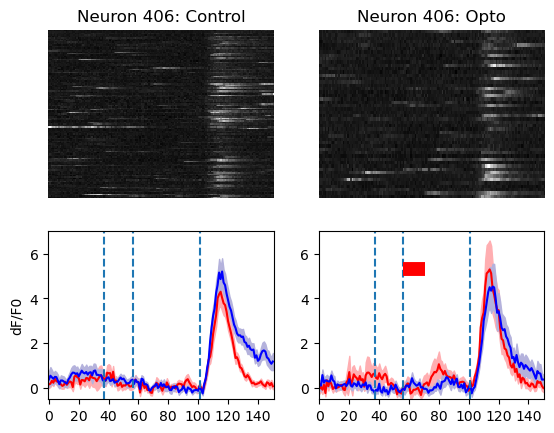

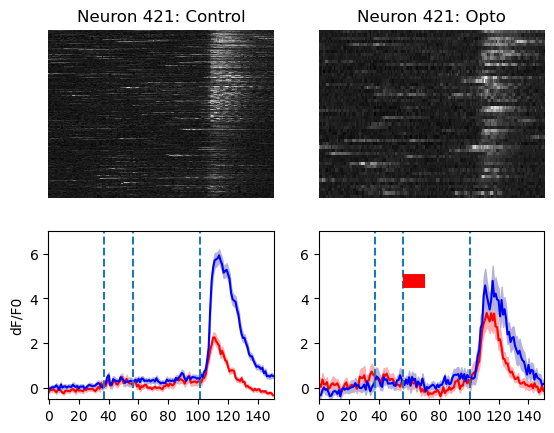

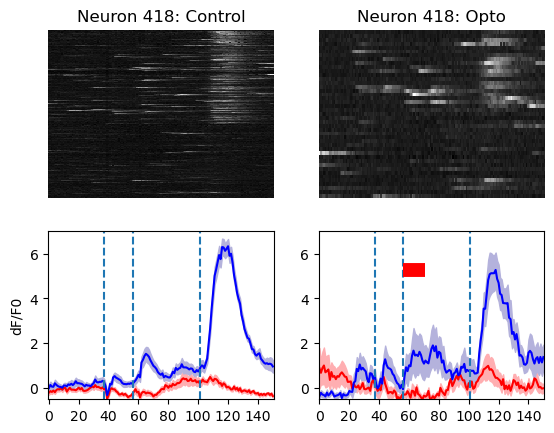

In [108]:
l0.plot_rasterPSTH_sidebyside(406, save=r'P:\paperfigures\fig2\resp_n_naive.pdf', fixaxis=(-0.5,7))
s1.plot_rasterPSTH_sidebyside(421, save=r'P:\paperfigures\fig2\resp_n_learning.pdf', fixaxis=(-0.5,7))
l2.plot_rasterPSTH_sidebyside(418, save=r'P:\paperfigures\fig2\resp_n_expert.pdf', fixaxis=(-0.5,7))

In [107]:
l0.good_neurons[np.where(s1.good_neurons == 421)[0][0]]

np.int32(406)

Minimum cutoff is 151
No water leak!
normalizing
-1.0447433
-1.0447433
Minimum cutoff is 151
No water leak!
normalizing
0.69177914
0.69177914
Minimum cutoff is 151
No water leak!
normalizing
-1.0262026
-1.0262026
0.9528238773345947
1.2840702533721924


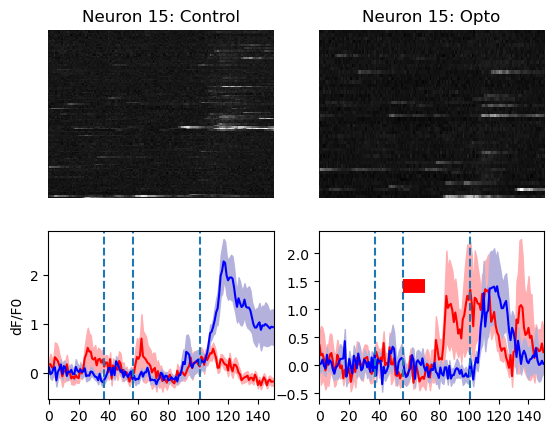

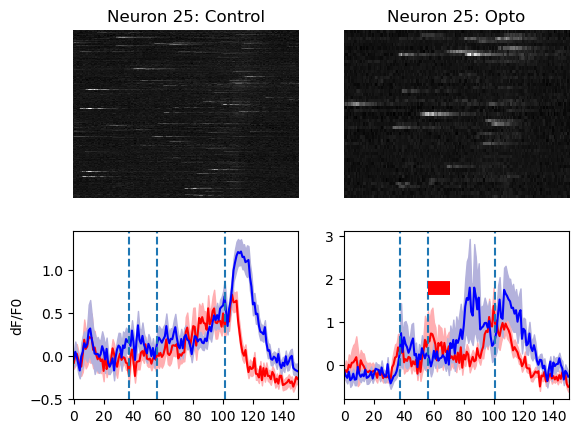

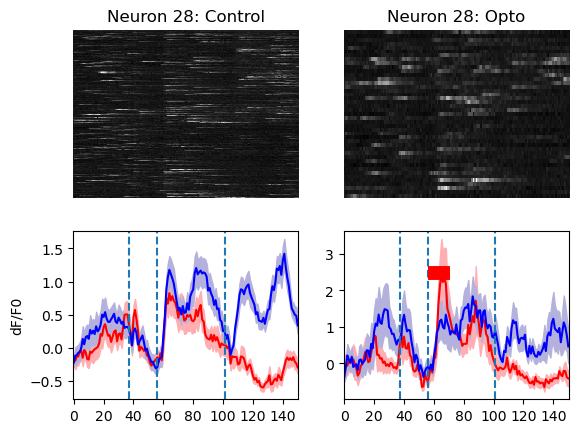

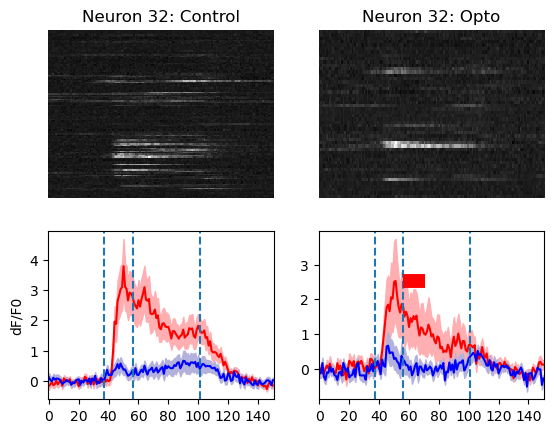

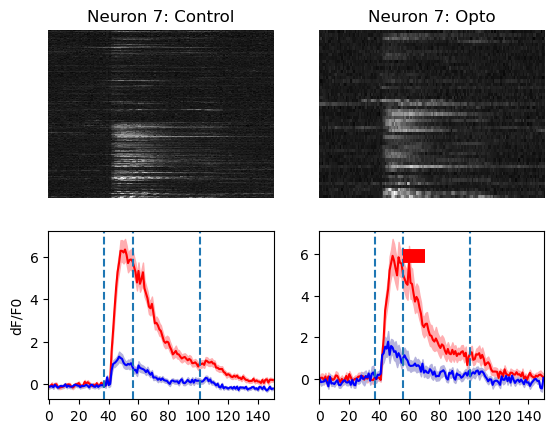

...

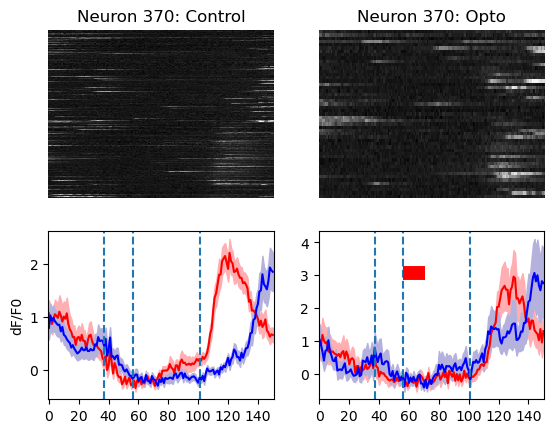

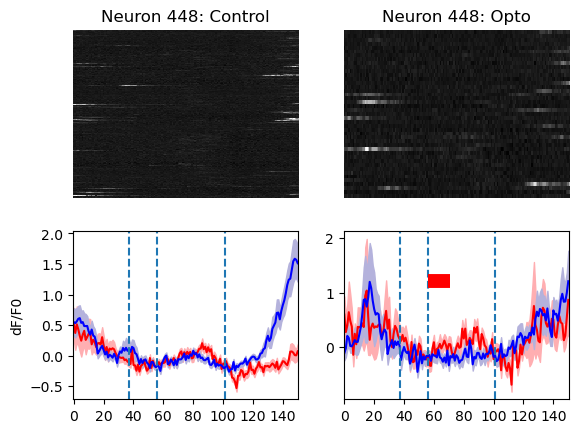

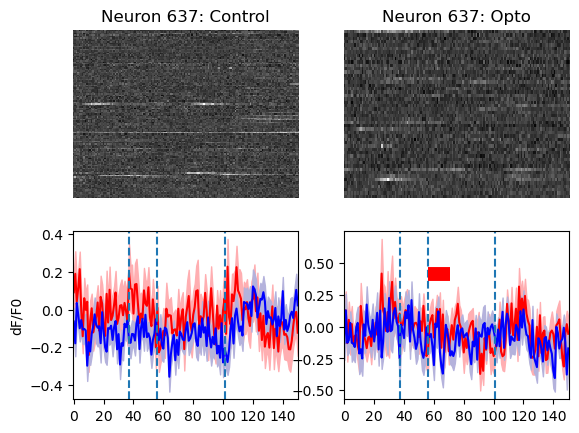

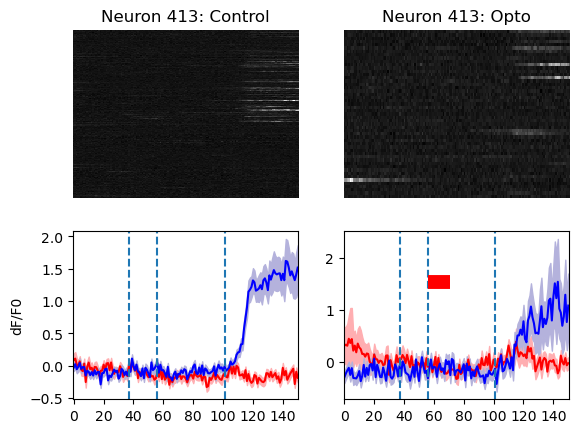

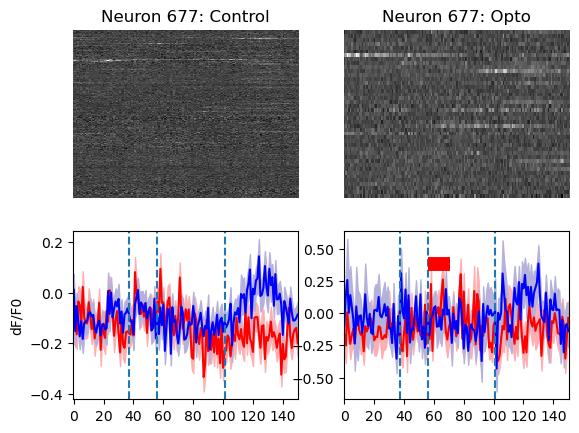

In [106]:
# for paths in all_matched_paths:

naivepath, learningpath, expertpath =  [r'F:\data\BAYLORCW035\python\2023_10_26',
    r'F:\data\BAYLORCW035\python\2023_12_07',
    r'F:\data\BAYLORCW035\python\2023_12_15',]

    
naivepath, learningpath, expertpath = [r'H:\data\BAYLORCW046\python\2024_05_31',
             r'H:\data\BAYLORCW046\python\2024_06_11',
             r'H:\data\BAYLORCW046\python\2024_06_26'
             ]


s1 = session.Session(learningpath, use_reg = True, triple=True, baseline_normalization="median_zscore")
l0 =  session.Session(naivepath, use_reg = True, triple=True, baseline_normalization="median_zscore")
l2 =  session.Session(expertpath, use_reg = True, triple=True, baseline_normalization="median_zscore")

naivedelaysel = l0.get_epoch_selective(range(l0.response, l0.response+20))
for i in s1.get_epoch_selective(range(l0.response, l0.response+20)):
    n = l0.good_neurons[np.where(s1.good_neurons == i)[0][0]]
    nexp = l2.good_neurons[np.where(s1.good_neurons == i)[0][0]]
    if n not in naivedelaysel:
        l0.plot_rasterPSTH_sidebyside(n)
        s1.plot_rasterPSTH_sidebyside(i)
        l2.plot_rasterPSTH_sidebyside(nexp)

### Proportion selective NLE

Minimum cutoff is 151
No water leak!
normalizing
-0.12740667
-0.12740667
Minimum cutoff is 151
No water leak!
normalizing
-5.6991854
-5.6991854
Minimum cutoff is 151
No water leak!
normalizing
-1.2221651
-1.2221651
Minimum cutoff is 151
No water leak!
normalizing
-3.4967453
-3.4967453
Minimum cutoff is 151
No water leak!
normalizing
0.69177914
0.69177914
Minimum cutoff is 61
No water leak!
normalizing
-0.4516898
-0.4516898
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
Minimum cutoff is 61
No water leak!
normalizing
-0.32274458
-0.32274458
Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901


IndexError: index 6 is out of bounds for axis 0 with size 6

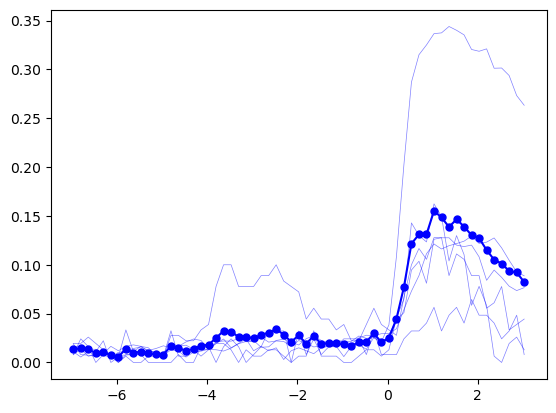

In [ ]:

# Aggregate plot NAIVE ##
allcontra, allipsi = [], []
# new sessions


allpaths = [
        [r'H:\data\BAYLORCW044\python\2024_05_22',
        r'H:\data\BAYLORCW044\python\2024_05_23',],
        
        [r'H:\data\BAYLORCW046\python\2024_05_29',
        r'H:\data\BAYLORCW046\python\2024_05_30',
        r'H:\data\BAYLORCW046\python\2024_05_31',]

        ]
for paths in allpaths:
    cmean  = []
    for path in paths:
        l1 = session.Session(path, use_reg=True, triple=True)
        contra, ipsi = l1.plot_number_of_sig_neurons(return_nums=True)

        contra = contra + ipsi
        
        x = np.arange(-6.97,6,1/30)[:l1.time_cutoff*2]
        nums = np.interp(x, np.arange(-6.97,6,1/15)[:l1.time_cutoff], contra)
        contra = scipy.signal.decimate(nums, 5)
        cmean += [contra/len(l1.good_neurons)]

    allcontra += [np.mean(cmean, axis=0)]

paths = [
        r'F:\data\BAYLORCW032\python\2023_10_08',
        # r'F:\data\BAYLORCW034\python\2023_10_12',
        r'F:\data\BAYLORCW036\python\2023_10_09',
        r'F:\data\BAYLORCW035\python\2023_10_26',
        r'F:\data\BAYLORCW037\python\2023_11_21',
        ]
for path in paths:
    l1 = session.Session(path, use_reg=True, triple=True)
    contra, ipsi = l1.plot_number_of_sig_neurons(return_nums=True)
    contra = contra + ipsi
    allcontra = np.vstack((allcontra, contra/len(l1.good_neurons)))
    
    


C:\Users\catherinewang\AppData\Local\Temp\ipykernel_8960\427616644.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


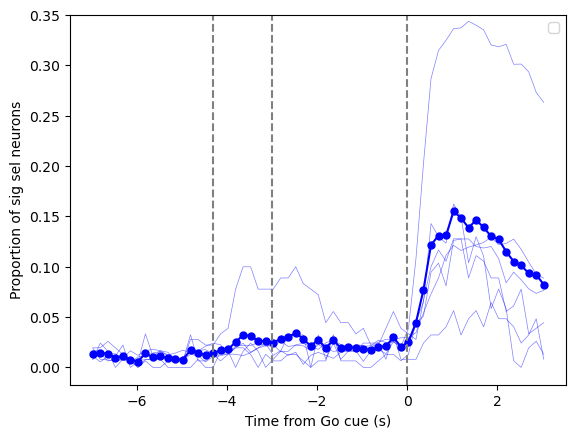

In [198]:
x = np.arange(-6.97,6,1/6)[:61] # Downsample everything to this

plt.plot(x, np.mean(allcontra, axis=0), color = 'b', marker = 'o', markersize=5)

for i in range(6):
    plt.plot(x, allcontra[i], color = 'b', alpha = 0.5, linewidth = 0.5)

plt.axvline(-4.3, ls='--', color='grey')
plt.axvline(-3, ls='--', color='grey')
plt.axvline(0, ls='--', color='grey')
# plt.ylim(bottom = -350)
plt.ylim(top = 0.35)
plt.ylabel('Proportion of sig sel neurons')
plt.xlabel('Time from Go cue (s)')
plt.legend()

plt.show()

Minimum cutoff is 151
No water leak!
normalizing
-3.0620294
-3.0620294
Minimum cutoff is 151
No water leak!
normalizing
1.3271582
1.3271582
Minimum cutoff is 151
No water leak!
normalizing
-2.1285305
-0.8998496
Minimum cutoff is 151
No water leak!
normalizing
-2.5499787
-2.5499787
Minimum cutoff is 151
No water leak!
normalizing
-1.0447433
-1.0447433
Minimum cutoff is 61
No water leak!
normalizing
1.527321
1.527321
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Minimum cutoff is 61
No water leak!
normalizing
-2.061139
-2.061139
Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302


C:\Users\catherinewang\AppData\Local\Temp\ipykernel_8960\4166808670.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


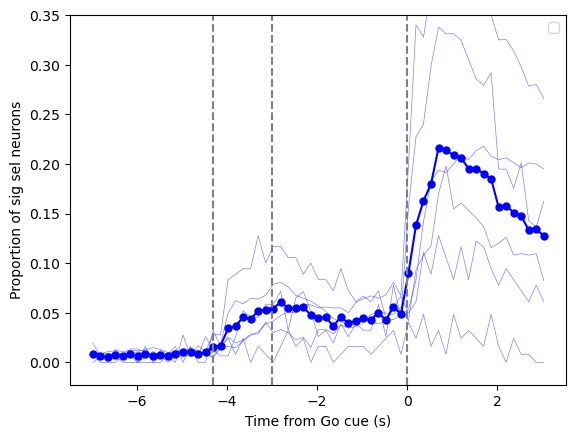

In [200]:

allcontra, allipsi = [], []
# new sessions


allpaths = [
        [r'H:\data\BAYLORCW044\python\2024_06_06',
        r'H:\data\BAYLORCW044\python\2024_06_04',],
        
       [ r'H:\data\BAYLORCW046\python\2024_06_07',
        r'H:\data\BAYLORCW046\python\2024_06_10',
        r'H:\data\BAYLORCW046\python\2024_06_11',]

        ]
for paths in allpaths:
    cmean  = []
    for path in paths:
        l1 = session.Session(path, use_reg=True, triple=True)
        contra, ipsi = l1.plot_number_of_sig_neurons(return_nums=True)
        contra = contra + ipsi

        x = np.arange(-6.97,6,1/30)[:l1.time_cutoff*2]
        nums = np.interp(x, np.arange(-6.97,6,1/15)[:l1.time_cutoff], contra)
        contra = scipy.signal.decimate(nums, 5)
        cmean += [contra/len(l1.good_neurons)]
    allcontra += [np.mean(cmean, axis=0)]

paths = [
        r'F:\data\BAYLORCW032\python\2023_10_16',
        # r'F:\data\BAYLORCW034\python\2023_10_22',
        r'F:\data\BAYLORCW036\python\2023_10_19',
        r'F:\data\BAYLORCW035\python\2023_12_07',
        r'F:\data\BAYLORCW037\python\2023_12_08',
        ]
for path in paths:
    l1 = session.Session(path, use_reg=True, triple=True)
    contra, ipsi = l1.plot_number_of_sig_neurons(return_nums=True)
    contra = contra + ipsi

    allcontra = np.vstack((allcontra, contra/len(l1.good_neurons)))    
    
x = np.arange(-6.97,6,1/6)[:61] # Downsample everything to this

plt.plot(x, np.mean(allcontra, axis=0), color = 'b', marker = 'o', markersize=5)

for i in range(6):
    plt.plot(x, allcontra[i], color = 'b', alpha = 0.5, linewidth = 0.5)

plt.axvline(-4.3, ls='--', color='grey')
plt.axvline(-3, ls='--', color='grey')
plt.axvline(0, ls='--', color='grey')
# plt.ylim(bottom = -350)
plt.ylim(top = 0.35)
plt.ylabel('Proportion of sig sel neurons')
plt.xlabel('Time from Go cue (s)')
plt.legend()

plt.show()

Minimum cutoff is 152
No water leak!
normalizing
-0.30559444
-0.30559444
Minimum cutoff is 152
No water leak!
normalizing
-1.364392
-1.364392
Minimum cutoff is 151
No water leak!
normalizing
0.39554286
0.39554286
Minimum cutoff is 151
No water leak!
normalizing
0.53977877
0.53977877
Minimum cutoff is 151
No water leak!
normalizing
-1.0262026
-1.0262026
Minimum cutoff is 61
No water leak!
normalizing
-2.6254678
-2.6254678
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Minimum cutoff is 61
No water leak!
normalizing
1.7143317
1.7143317
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567


C:\Users\catherinewang\AppData\Local\Temp\ipykernel_8960\1292418288.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


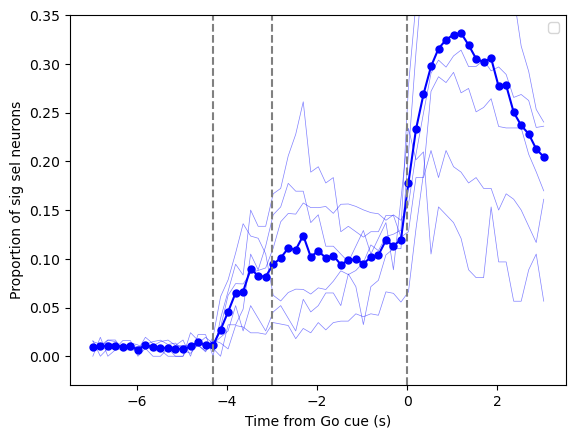

In [201]:
allcontra, allipsi = [], []
#original sessions
paths = [r'F:\data\BAYLORCW032\python\2023_10_24',
        # r'F:\data\BAYLORCW034\python\2023_10_27',
        r'F:\data\BAYLORCW036\python\2023_10_28']



allpaths = [
        [r'H:\data\BAYLORCW044\python\2024_06_19',
        r'H:\data\BAYLORCW044\python\2024_06_18',],
        
        [r'H:\data\BAYLORCW046\python\2024_06_24',
        r'H:\data\BAYLORCW046\python\2024_06_27',
        r'H:\data\BAYLORCW046\python\2024_06_26',]

        ]
for paths in allpaths:
    cmean  = []
    for path in paths:
        l1 = session.Session(path, use_reg=True, triple=True)
        contra, ipsi = l1.plot_number_of_sig_neurons(return_nums=True)
        contra = contra + ipsi
        contra = contra[:151]

        x = np.arange(-6.97,6,1/30)[:l1.time_cutoff*2]
        nums = np.interp(x, np.arange(-6.97,6,1/15)[:151], contra)
        contra = scipy.signal.decimate(nums, 5)
        cmean += [contra/len(l1.good_neurons)]
    allcontra += [np.mean(cmean, axis=0)]
    
#testing new sessions
paths = [
        r'F:\data\BAYLORCW032\python\2023_10_25',
        # r'F:\data\BAYLORCW034\python\2023_10_27',
        r'F:\data\BAYLORCW036\python\2023_10_30',
        r'F:\data\BAYLORCW035\python\2023_12_15',
        r'F:\data\BAYLORCW037\python\2023_12_15',
        ]
for path in paths:
    l1 = session.Session(path, use_reg=True, triple=True)
    contra, ipsi = l1.plot_number_of_sig_neurons(return_nums=True)
    contra = contra + ipsi
    
    allcontra = np.vstack((allcontra, contra/len(l1.good_neurons)))
    
    
x = np.arange(-6.97,6,1/6)[:61] # Downsample everything to this

plt.plot(x, np.mean(allcontra, axis=0), color = 'b', marker = 'o', markersize=5)

for i in range(6):
    plt.plot(x, allcontra[i], color = 'b', alpha = 0.5, linewidth = 0.5)

plt.axvline(-4.3, ls='--', color='grey')
plt.axvline(-3, ls='--', color='grey')
plt.axvline(0, ls='--', color='grey')
# plt.ylim(bottom = -350)
plt.ylim(top = 0.35)
plt.ylabel('Proportion of sig sel neurons')
plt.xlabel('Time from Go cue (s)')
plt.legend()
# 
plt.show()

## Sankey contra vs ipsi turnover

In [10]:
all_matched_paths[0]

all_matched_paths

[['F:\\data\\BAYLORCW032\\python\\2023_10_05',
  'F:\\data\\BAYLORCW032\\python\\2023_10_19',
  'F:\\data\\BAYLORCW032\\python\\2023_10_24'],
 ['F:\\data\\BAYLORCW036\\python\\2023_10_09',
  'F:\\data\\BAYLORCW036\\python\\2023_10_19',
  'F:\\data\\BAYLORCW036\\python\\2023_10_30'],
 ['F:\\data\\BAYLORCW037\\python\\2023_11_21',
  'F:\\data\\BAYLORCW037\\python\\2023_12_08',
  'F:\\data\\BAYLORCW037\\python\\2023_12_15'],
 ['F:\\data\\BAYLORCW035\\python\\2023_10_26',
  'F:\\data\\BAYLORCW035\\python\\2023_12_07',
  'F:\\data\\BAYLORCW035\\python\\2023_12_15'],
 ['H:\\data\\BAYLORCW044\\python\\2024_05_22',
  'H:\\data\\BAYLORCW044\\python\\2024_06_06',
  'H:\\data\\BAYLORCW044\\python\\2024_06_19'],
 ['H:\\data\\BAYLORCW044\\python\\2024_05_23',
  'H:\\data\\BAYLORCW044\\python\\2024_06_04',
  'H:\\data\\BAYLORCW044\\python\\2024_06_18'],
 ['H:\\data\\BAYLORCW046\\python\\2024_05_29',
  'H:\\data\\BAYLORCW046\\python\\2024_06_24',
  'H:\\data\\BAYLORCW046\\python\\2024_06_28'],
 ['H:\

In [11]:

p=0.01

og_SDR = []
c1, i1, ns1 = np.zeros(3),np.zeros(3),np.zeros(3)
for paths in all_matched_paths: # For each mouse

    s1 = session.Session(paths[1], use_reg=True, triple=True) # Naive
    # epoch = range(s1.response, s1.time_cutoff) # response selective
    epoch = range(s1.delay + 9, s1.response) # delay selective
    
    contra_neurons, ipsi_neurons, _, _ = s1.contra_ipsi_pop(epoch, p=p)
    naive_nonsel = [n for n in s1.good_neurons if n not in ipsi_neurons and n not in contra_neurons]

    og_SDR += [[len(contra_neurons), len(ipsi_neurons), len(naive_nonsel)]]

    s2 = session.Session(paths[2], use_reg=True, triple=True) # Learning
    # s2 = session.Session(paths[0][2], use_reg=True, triple=True) # Expert

    # learning = sum([s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch) for n in naive_sel])
    # expert = sum([s3.is_selective(s3.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch) for n in naive_sel])
    
    for n in contra_neurons:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch, p=p):
            ipsi, _, _ = s2.screen_preference(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch)
            if not ipsi:
                c1[0] += 1
            else:
                c1[1] += 1
        else:
            c1[2] += 1
    
    for n in ipsi_neurons:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch, p=p):
            ipsi, _, _ = s2.screen_preference(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch)
            if not ipsi:
                i1[0] += 1
            else:
                i1[1] += 1
        else:
            i1[2] += 1
    

    for n in naive_nonsel:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch, p=p):
            ipsi, _, _ = s2.screen_preference(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], epoch)
            if not ipsi:
                ns1[0] += 1
            else:
                ns1[1] += 1
        else:
            ns1[2] += 1
    
og_SDR = np.sum(og_SDR, axis=0)

Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
0.8129348754882812
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
0.7349817752838135
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302
3.1215062141418457
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567
Minimum cutoff is 61
No water leak!
normalizing
-2.061139
-2.061139
0.6951959133148193
Minimum cutoff is 61
No water leak!
normalizing
1.7143317
1.7143317
Minimum cutoff is 151
No water leak!
normalizing
-3.0620294
-3.0620294
1.8012542724609375
Minimum cutoff is 152
No water leak!
normalizing
-0.30559444
-0.30559444
Minimum cutoff is 151
No water leak!
normalizing
1.3271582
1.3271582
3.2239034175872803
Minimum cutoff is 152
No water leak!
normalizing
-1.364392
-1.364392
Minimum cutoff is 151
No water leak!
normalizing
0.39554286


In [12]:
c1, i1, ns1

(array([32.,  9., 78.]),
 array([  5., 126., 111.]),
 array([ 178.,  184., 2310.]))

In [ ]:
# Naive to learning:

# Contra[3] Contra1
# Contra[1] Ipsi1
# Contra[50] NS1

# Ipsi[1] Contra1
# Ipsi[30] Ipsi1
# Ipsi[38] NS1


# NS[116] Contra1
# NS[210] Ipsi1
# //NS[2584] NS1



# Learning to expert:

# Contra1[32]Contra2
# Contra1[9]Ipsi2
# Contra1[78]NS2

# Ipsi1[5]Contra2
# Ipsi1[126]Ipsi2
# Ipsi1[111]NS2

# NS1[178]Contra2
# NS1[184]Ipsi2
# //NS1[2310]NS2
# NS1[10]NS2



# Coloring:

# :Ipsi1 #FF0000
# :Ipsi #FF0000
# :Ipsi2 #FF0000

# :Contra #1F77B4
# :Contra1 #1F77B4
# :Contra2 #1F77B4

# :NS #808080
# :NS1 #808080
# :NS2 #808080

## Early lick analysis

### Early lick over stages

In [71]:
all_nle_el = []

for paths in all_matched_paths:
    nle_el = []
    naivepath, learningpath, expertpath = paths
    for p in [naivepath, learningpath, expertpath]:
        s2 = session.Session(p)
        nle_el += [sum(s2.early_lick)/len(s2.early_lick)]
    all_nle_el += [nle_el]

Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567
Using Pearsons corr to filter neurons.

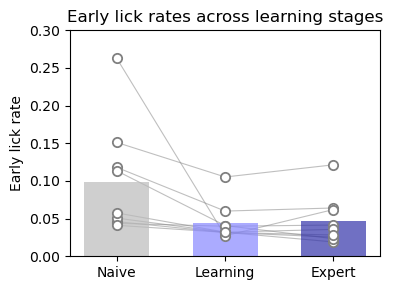

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Convert early lick rates to numpy array for easy averaging
all_nle_el_arr = np.array(all_nle_el)  # shape (n_animals, 3)

x = np.arange(3)  # 0: naive, 1: learning, 2: expert
means = np.mean(all_nle_el_arr, axis=0)
stds = np.std(all_nle_el_arr, axis=0)  # (optional, for error bars)

fig, ax = plt.subplots(figsize=(4,3))

# Plot the bars
bar_colors = ['#bbbbbb', '#8888ff', '#3333aa']
ax.bar(x, means, color=bar_colors, alpha=0.7, width=0.6, zorder=1)

# Plot each individual animal as a scatter and connect them
for i, animal_rates in enumerate(all_nle_el_arr):
    ax.scatter(x, animal_rates, facecolor='white', edgecolor='grey', linewidth=1.3, zorder=2, s=45)
    ax.plot(x, animal_rates, color='grey', alpha=0.5, linewidth=0.8, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(['Naive', 'Learning', 'Expert'])
ax.set_ylabel('Early lick rate')
ax.set_title('Early lick rates across learning stages')
ax.set_ylim(0, 0.3)
plt.tight_layout()
plt.savefig(r'P:\paperfigures\EL_rates_imaging.pdf')
plt.show()

### Early licks projected on expert choice CD

Minimum cutoff is 61
No water leak!
normalizing
0.5582764
0.5582764
in house train test sorting
Sort by lick dir
Runtime: 0.019565820693969727 secs


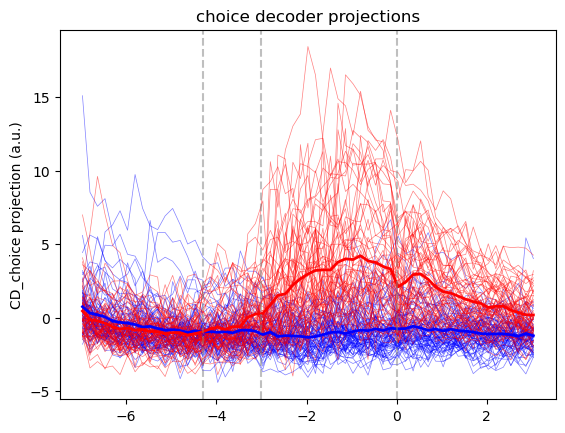

Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857


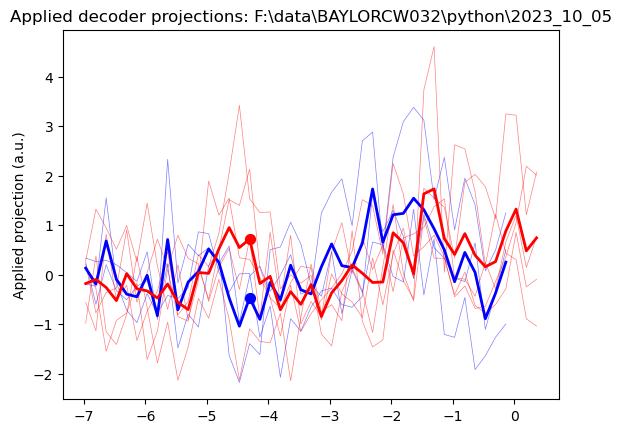

Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724


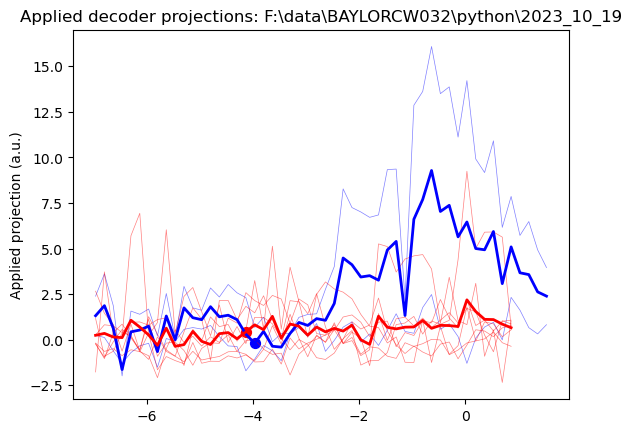

Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431


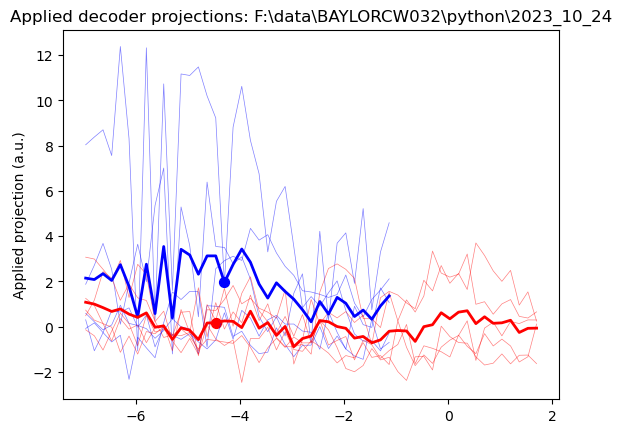

Minimum cutoff is 61
No water leak!
normalizing
-0.8164738
-0.8164738
in house train test sorting
Sort by lick dir
Runtime: 0.003992795944213867 secs


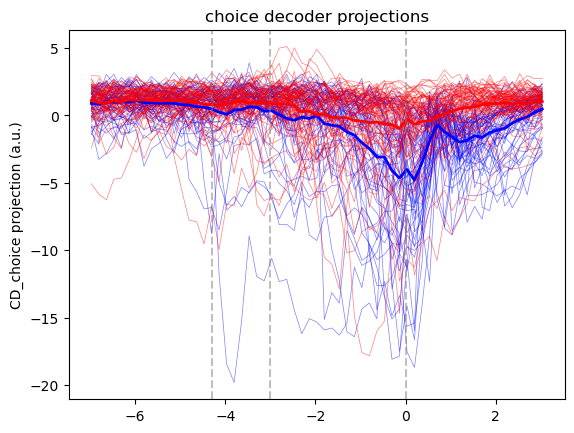

Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046


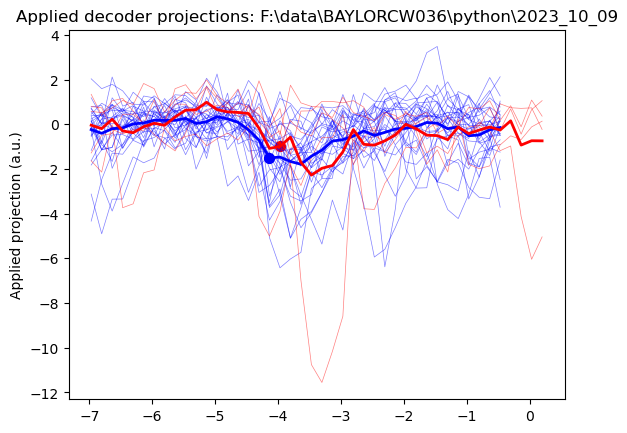

Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193


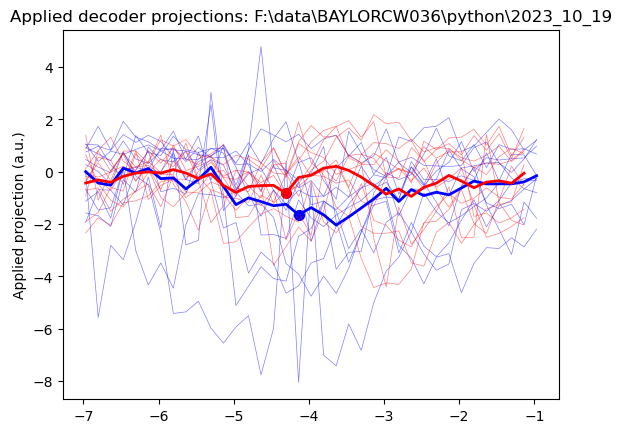

Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582


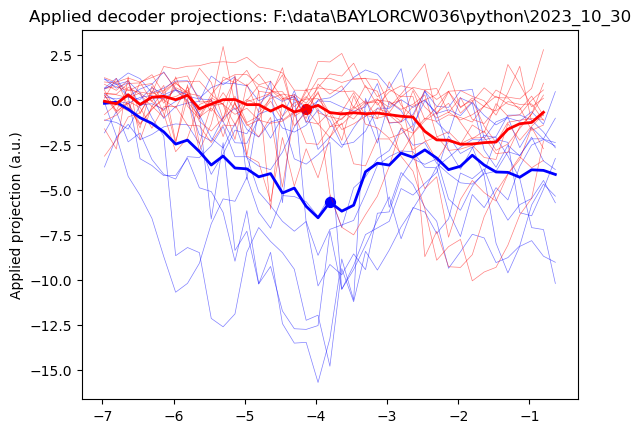

Minimum cutoff is 61
No water leak!
normalizing
-0.10009959
-0.10009959
in house train test sorting
Sort by lick dir
Runtime: 0.04954338073730469 secs


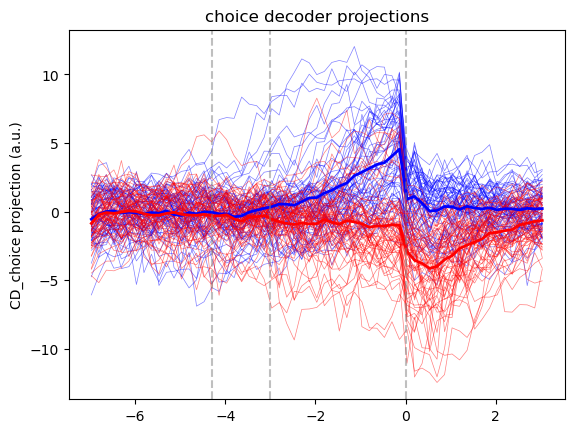

Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901


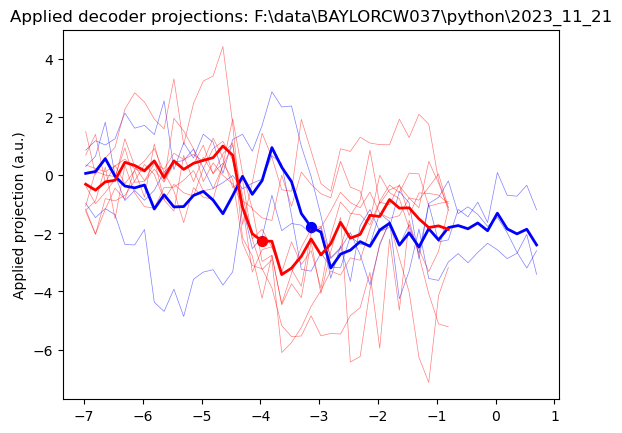

Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567


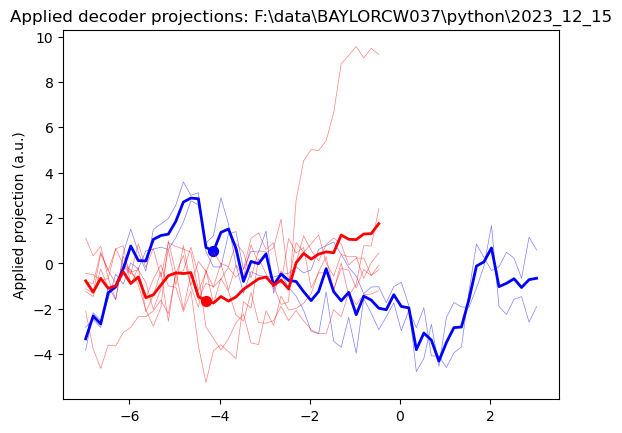

Minimum cutoff is 61
No water leak!
normalizing
-0.34847012
-0.34847012
in house train test sorting
Sort by lick dir
Runtime: 0.005995750427246094 secs


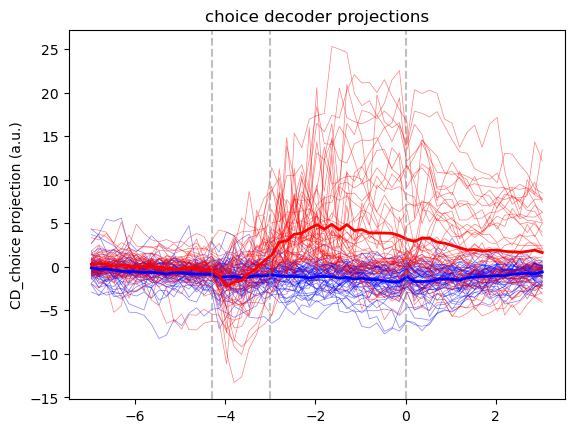

Minimum cutoff is 61
No water leak!
normalizing
-0.32274458
-0.32274458


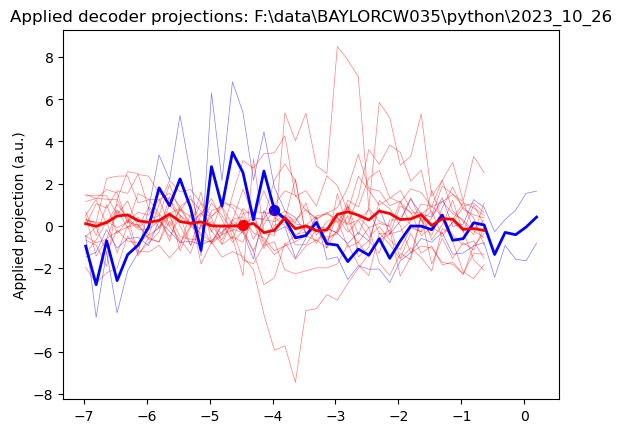

Minimum cutoff is 61
No water leak!
normalizing
-2.061139
-2.061139


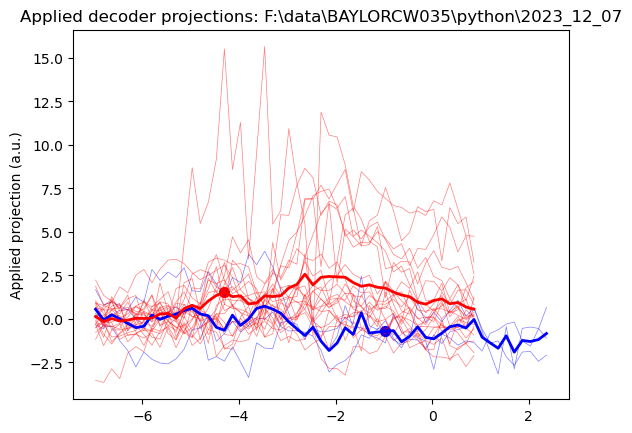

Minimum cutoff is 61
No water leak!
normalizing
1.7143317
1.7143317


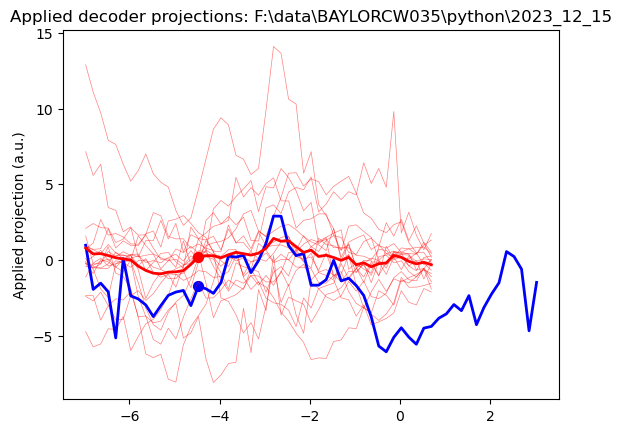

Minimum cutoff is 152
No water leak!
normalizing
-0.19548415
-0.19548415
in house train test sorting
Sort by lick dir
Runtime: 0.012001514434814453 secs


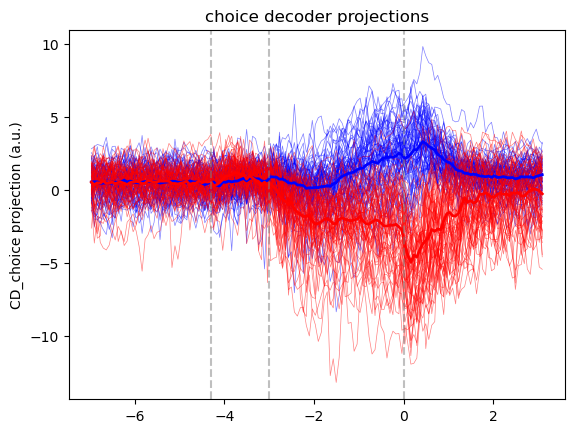

Minimum cutoff is 151
No water leak!
normalizing
-0.12740667
-0.12740667


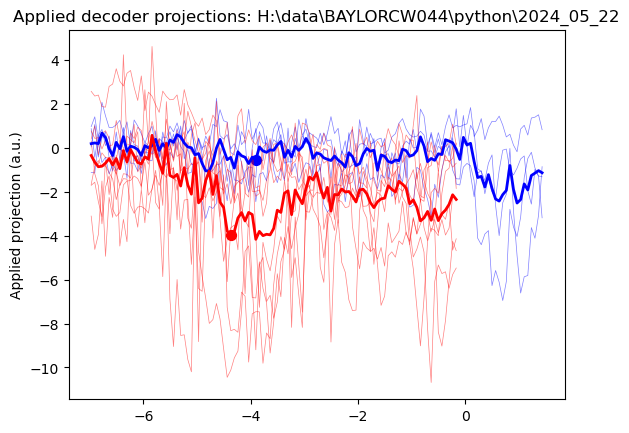

Minimum cutoff is 151
No water leak!
normalizing
-3.0620294
-3.0620294


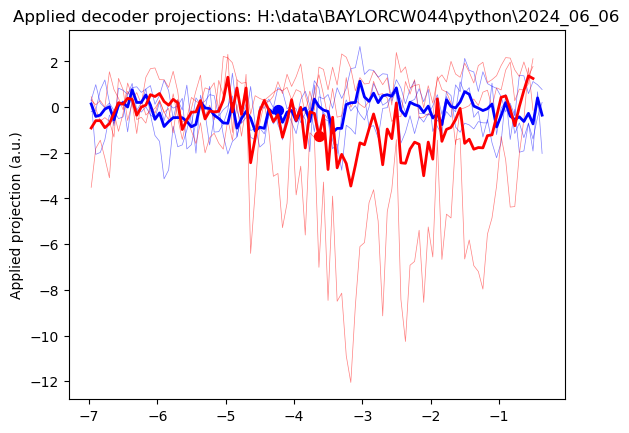

Minimum cutoff is 152
No water leak!
normalizing
-0.30559444
-0.30559444


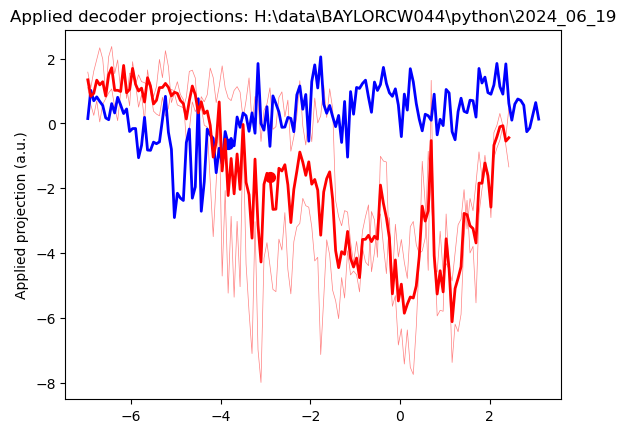

Minimum cutoff is 152
No water leak!
normalizing
-0.7403479
-0.7403479
in house train test sorting
Sort by lick dir
Runtime: 0.0370028018951416 secs


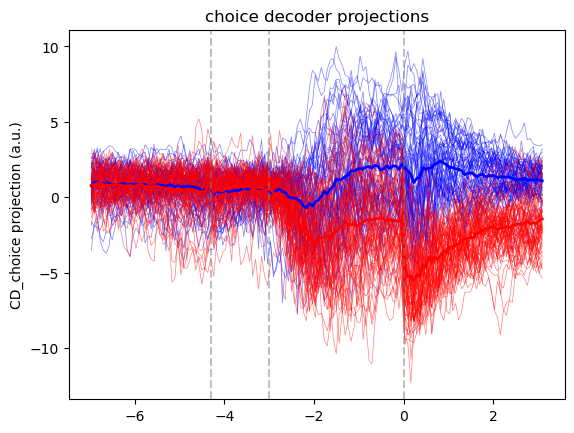

Minimum cutoff is 151
No water leak!
normalizing
-5.6991854
-5.6991854


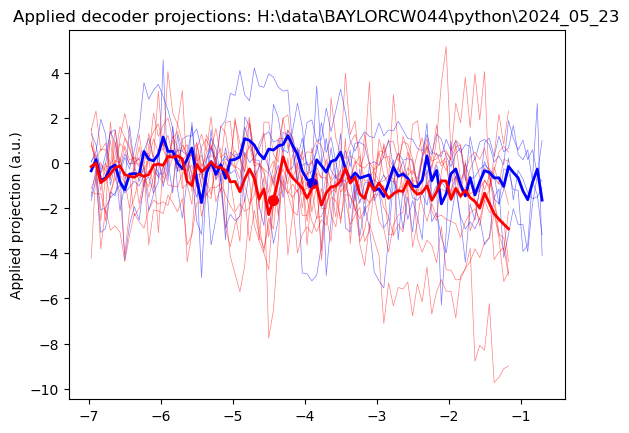

Minimum cutoff is 151
No water leak!
normalizing
1.3271582
1.3271582


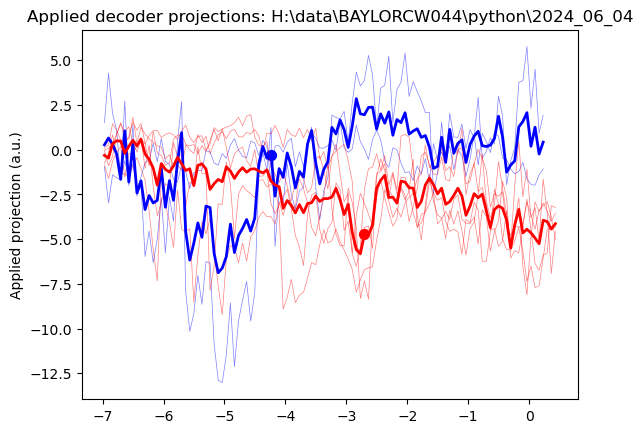

Minimum cutoff is 152
No water leak!
normalizing
-1.364392
-1.364392


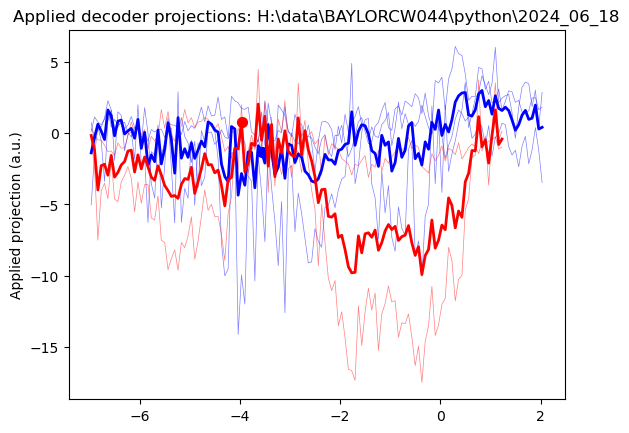

Minimum cutoff is 151
No water leak!
normalizing
-0.25491297
-0.54721725
in house train test sorting
Sort by lick dir
Runtime: 0.01599860191345215 secs


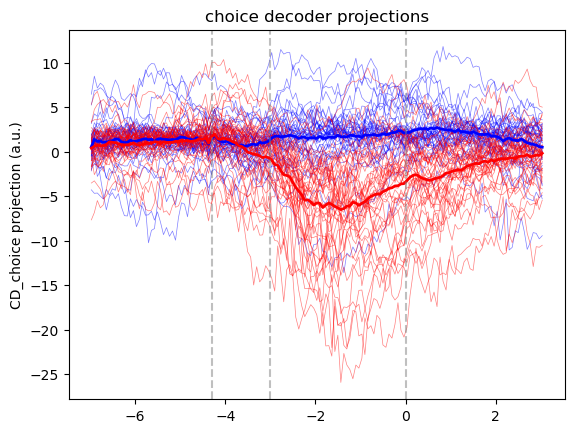

Minimum cutoff is 151
No water leak!
normalizing
-1.2221651
-1.2221651


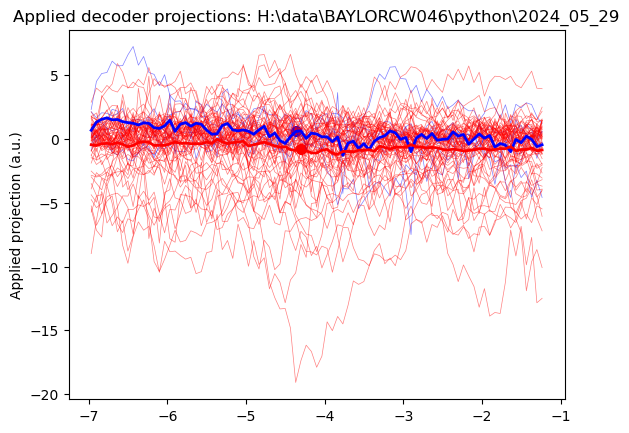

Minimum cutoff is 151
No water leak!
normalizing
0.39554286
0.39554286
Minimum cutoff is 151
No water leak!
normalizing
1.7709097
0.42789528


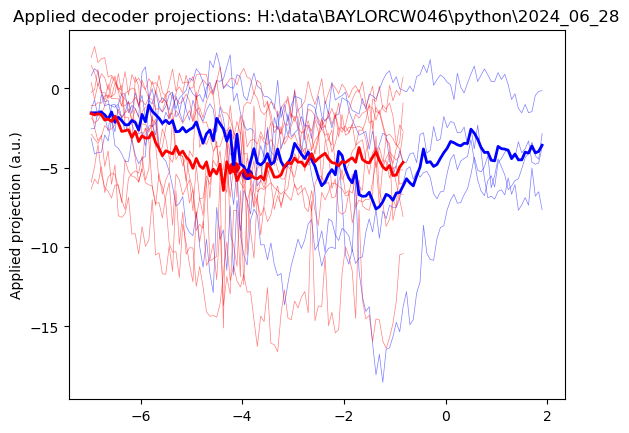

Minimum cutoff is 151
No water leak!
normalizing
0.062847145
0.062847145
in house train test sorting
Sort by lick dir
Runtime: 0.007996559143066406 secs


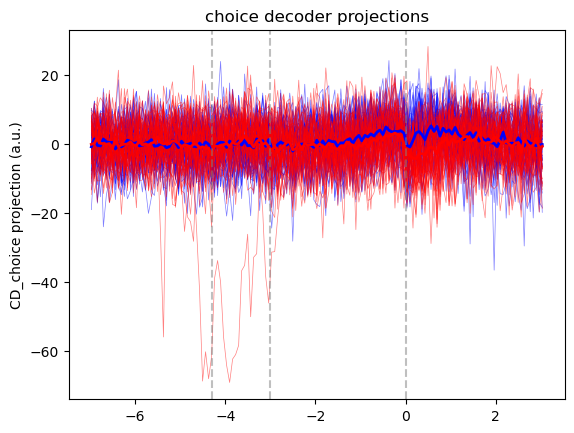

Minimum cutoff is 151
No water leak!
normalizing
-3.4967453
-3.4967453


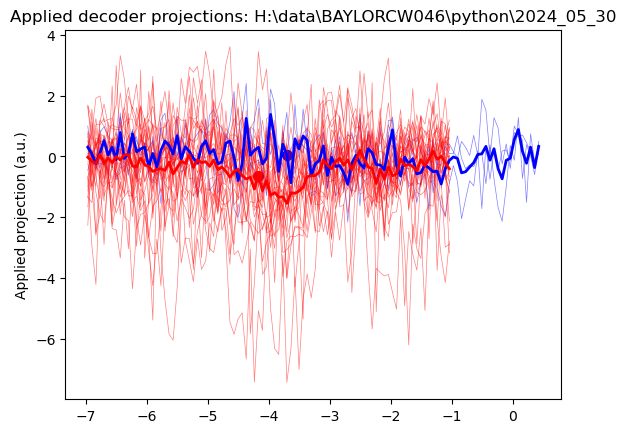

Minimum cutoff is 151
No water leak!
normalizing
-2.5499787
-2.5499787


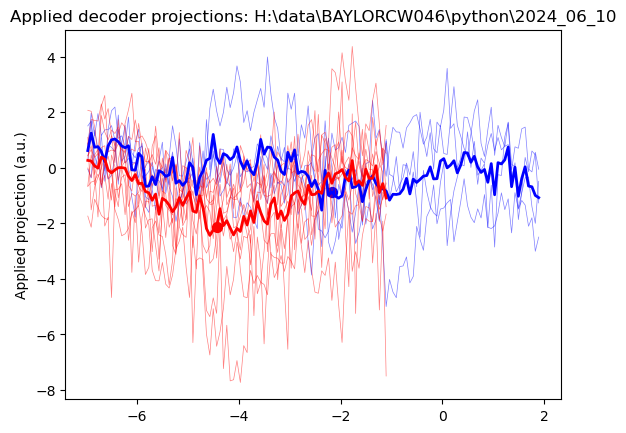

Minimum cutoff is 151
No water leak!
normalizing
0.53977877
0.53977877
Minimum cutoff is 151
No water leak!
normalizing
0.38055593
0.38055593
in house train test sorting
Sort by lick dir
Runtime: 0.009005069732666016 secs


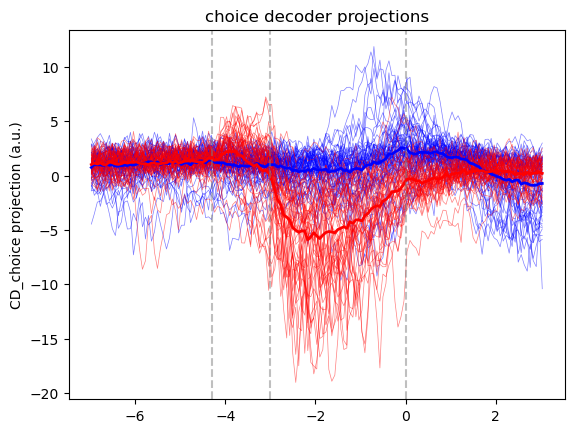

Minimum cutoff is 151
No water leak!
normalizing
0.69177914
0.69177914
Minimum cutoff is 151
No water leak!
normalizing
-1.0447433
-1.0447433


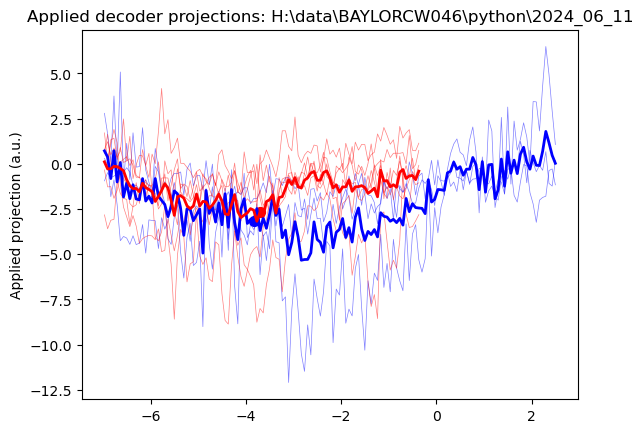

Minimum cutoff is 151
No water leak!
normalizing
-1.0262026
-1.0262026


In [13]:
lick_threshold = 1
# all_expert_proj, all_learning_proj, all_naive_proj = [],[],[]
agg_all_fov_proj_yes, agg_all_fov_proj_no = [],[]

for paths in all_matched_paths:
    naivepath, learningpath, expertpath = paths

    s2 = Mode(expertpath, use_reg = True, triple=True)

    CD_choice_mode, mean = s2.plot_CD(mode_input='choice', ctl=True)
    # calculate early lick CD in naive sessions - define here
    all_fov_proj_yes, all_fov_proj_no = [],[]
    for p in [naivepath, learningpath, expertpath]:
        s2 = session.Session(p, use_reg = True, triple=True)
    
        early_lick_trials = np.where(s2.early_lick)[0]
        early_lick_side = [i[0] for i in s2.early_lick_side] # use first lick as direction
        early_lick_time = [i[0][0] for i in s2.early_lick_time]
        
        # Filter out the early lick trials that happen too early (before end of 2.5 ITI)
        drop_idx = [i for i in range(len(early_lick_time)) if early_lick_time[i] > 2.5]
        early_lick_trials = np.array(early_lick_trials)[drop_idx]
        early_lick_side = np.array(early_lick_side)[drop_idx]
        early_lick_time = np.array(early_lick_time)[drop_idx]
        
        # project early lick CD
        r_trials = early_lick_trials[np.where(early_lick_side == 'r')[0]]
        l_trials = early_lick_trials[np.where(early_lick_side == 'l')[0]]
        
        r_trial_lick = early_lick_time[np.where(early_lick_side == 'r')[0]]
        l_trial_lick = early_lick_time[np.where(early_lick_side == 'l')[0]]
        # Get the frame where the early lick happened, per trial
        r_trial_lick = [np.round(r/s2.fs) for r in r_trial_lick] 
        l_trial_lick = [np.round(r/s2.fs) for r in l_trial_lick] 
        
        if len(r_trial_lick) < lick_threshold or len(l_trial_lick) < lick_threshold:
            continue

        # Align every trial to shortest early lick (new go cue time)
        r_cue, l_cue = min(r_trial_lick), min(l_trial_lick)
        r_end, l_end = max(r_trial_lick), max(l_trial_lick)
        
        
        # get the train vs test indices
        all_r_idx, all_l_idx = np.arange(len(r_trials)), np.arange(len(l_trials))
        rtmp = np.random.permutation(len(all_r_idx))
        ltmp = np.random.permutation(len(all_l_idx))
        test_r_idx = rtmp
        test_l_idx = ltmp
        
        # compile train vs test psths
        PSTH_yes_correct, PSTH_no_correct = [], []
        PSTH_yes_correct_test, PSTH_no_correct_test = [], []
        PSTH_yes_correct_test_mean, PSTH_no_correct_test_mean = [], []
        for n in s2.good_neurons:
            
            r, l = s2.get_trace_matrix(n, rtrials=r_trials, ltrials=l_trials)
            
            for idx in range(len(r)): # adjust each trial to new go cue
                tmp = r[idx][int(r_trial_lick[idx] - r_cue) : ]
                r[idx] = tmp[ : int(s2.time_cutoff - (r_end-r_cue))]
            for idx in range(len(l)): # adjust each trial to new go cue
                tmp = l[idx][int(l_trial_lick[idx] - l_cue) : ]
                l[idx] = tmp[ : int(s2.time_cutoff - (l_end-l_cue))]
                
            r,l = np.array(r), np.array(l)
            
            r_test_mean = np.mean(r[test_r_idx], axis=0)
            l_test_mean = np.mean(l[test_l_idx], axis=0)
            
            r_test = r[test_r_idx]
            l_test = l[test_l_idx]
            PSTH_yes_correct_test += [r_test]
            PSTH_no_correct_test += [l_test]   
            
            if len(PSTH_yes_correct_test_mean) == 0:
                PSTH_yes_correct_test_mean = np.reshape(r_test_mean, (1,-1))
                PSTH_no_correct_test_mean = np.reshape(l_test_mean, (1,-1))
                
            else: 
                PSTH_yes_correct_test_mean = np.concatenate((PSTH_yes_correct_test_mean, np.reshape(r_test_mean, (1,-1))), axis = 0)
                PSTH_no_correct_test_mean = np.concatenate((PSTH_no_correct_test_mean, np.reshape(l_test_mean, (1,-1))), axis = 0)
        
        PSTH_no_correct_test, PSTH_yes_correct_test = np.array(PSTH_no_correct_test), np.array(PSTH_yes_correct_test)
        
        # i_t_r = range(int(r_cue) - int(round(0.8*(1/s2.fs))), int(r_cue)+int(round(0.2*(1/s2.fs)))) # use 12 time steps before lick and 3 after lick
        # i_t_l = range(int(l_cue) - int(round(0.8*(1/s2.fs))), int(l_cue)+int(round(0.2*(1/s2.fs))))
        
        # wt = (PSTH_yes_correct[:, i_t_r] - PSTH_no_correct[:, i_t_l]) / 2
        # CD_choice_mode = np.mean(wt, axis=1)
        
        # project onto other early lick trials - do manually with realigned trials
        # s2.plot_appliedCD(CD_choice_mode, 0)
        x = np.arange(-6.97,4, s2.fs)[:PSTH_yes_correct_test.shape[2]]
        
        proj_allDimR = []
        for t in range(PSTH_yes_correct_test.shape[1]): # every trial
            activity = PSTH_yes_correct_test[:, t, :]
            proj_allDim = np.dot(activity.T, CD_choice_mode)
            proj_allDimR += [proj_allDim[:s2.time_cutoff]]
            plt.plot(x, proj_allDim[:s2.time_cutoff], 'b', alpha = 0.5,  linewidth = 0.5)
            
        x = np.arange(-6.97,4, s2.fs)[:PSTH_no_correct_test.shape[2]]
        
        proj_allDimL = []
        # for t in range(len(PSTH_no_correct_test)):
        for t in range(PSTH_no_correct_test.shape[1]): # every trial
            activity = PSTH_no_correct_test[:, t, :]
            proj_allDim = np.dot(activity.T, CD_choice_mode)
            proj_allDimL += [proj_allDim[:s2.time_cutoff]]
            plt.plot(x, proj_allDim[:s2.time_cutoff], 'r', alpha = 0.5, linewidth = 0.5)
        
        activityRL_test = np.concatenate((PSTH_yes_correct_test_mean, PSTH_no_correct_test_mean), axis=1)
        
        # Correct trials
        proj_allDim = np.dot(activityRL_test.T, CD_choice_mode)
        
        # ax = axs.flatten()[0]
        r_cue, l_cue = int(r_cue), int(l_cue)
        plt.plot(np.arange(-6.97,4, s2.fs)[:PSTH_yes_correct_test_mean.shape[1]], proj_allDim[:PSTH_yes_correct_test_mean.shape[1]], 'b', linewidth = 2)
        plt.plot(np.arange(-6.97,4, s2.fs)[:PSTH_no_correct_test_mean.shape[1]], proj_allDim[PSTH_yes_correct_test_mean.shape[1]:], 'r', linewidth = 2)
        plt.scatter([np.arange(-6.97,4, s2.fs)[r_cue]], [proj_allDim[:PSTH_yes_correct_test_mean.shape[1]][r_cue]], color='blue', s=50)
        plt.scatter([np.arange(-6.97,4, s2.fs)[l_cue]], [proj_allDim[PSTH_yes_correct_test_mean.shape[1]:][l_cue]], color='red', s=50)
        plt.title("Applied decoder projections: {}".format(p))
        # plt.axvline(-4.3, color = 'grey', alpha=0.5, ls = '--')
        # plt.axvline(-3, color = 'grey', alpha=0.5, ls = '--')
        # plt.axvline(0, color = 'grey', alpha=0.5, ls = '--')
        plt.ylabel('Applied projection (a.u.)')
        
            
        plt.show()
        yes_proj = proj_allDim[:PSTH_yes_correct_test_mean.shape[1]]
        no_proj = proj_allDim[PSTH_yes_correct_test_mean.shape[1]:]
        all_fov_proj_yes += [yes_proj[:r_cue]]
        all_fov_proj_no += [no_proj[:l_cue]]
        
        # r_sem = np.std(proj_allDimR,axis=0) / np.sqrt(len(proj_allDimR))
        # l_sem = np.std(proj_allDimL,axis=0) / np.sqrt(len(proj_allDimL))
        # plt.plot(np.arange(-6.97,4, s2.fs)[:PSTH_yes_correct_test_mean.shape[1]], proj_allDim[:PSTH_yes_correct_test_mean.shape[1]], 'b', linewidth = 2)
        # plt.plot(np.arange(-6.97,4, s2.fs)[:PSTH_no_correct_test_mean.shape[1]], proj_allDim[PSTH_yes_correct_test_mean.shape[1]:], 'r', linewidth = 2)
        # plt.fill_between(x=np.arange(-6.97,4, s2.fs)[:PSTH_yes_correct_test_mean.shape[1]], 
        #                 y1=proj_allDim[:PSTH_yes_correct_test_mean.shape[1]] - r_sem,
        #                 y2=proj_allDim[:PSTH_yes_correct_test_mean.shape[1]] + r_sem, color='lightblue')
        # plt.fill_between(x=np.arange(-6.97,4, s2.fs)[:PSTH_no_correct_test_mean.shape[1]], 
        #                 y1=proj_allDim[PSTH_yes_correct_test_mean.shape[1]:] - l_sem,
        #                 y2=proj_allDim[PSTH_yes_correct_test_mean.shape[1]:] + l_sem, color='pink')
        # plt.axvline(np.arange(-6.97,4, s2.fs)[r_cue], ls='--', c='black')
        # plt.axvline(np.arange(-6.97,4, s2.fs)[l_cue], ls='--', c='grey')
        # plt.title(naivepath)
        
        # plt.show()
    
    agg_all_fov_proj_yes.append(all_fov_proj_yes)
    agg_all_fov_proj_no.append(all_fov_proj_no)
    

    

In [53]:
[len(n) for n in agg_all_fov_proj_yes],[len(n) for n in agg_all_fov_proj_no]


([3, 3, 2, 3, 3, 3, 2, 2, 1], [3, 3, 2, 3, 3, 3, 2, 2, 1])

In [66]:
all_matched_paths[5]

['H:\\data\\BAYLORCW044\\python\\2024_05_23',
 'H:\\data\\BAYLORCW044\\python\\2024_06_04',
 'H:\\data\\BAYLORCW044\\python\\2024_06_18']

In [63]:
select_fovs = [0,1,3]
select_agg_all_fov_proj_yes = [agg_all_fov_proj_yes[i] for i in select_fovs]
select_agg_all_fov_proj_no = [agg_all_fov_proj_no[i] for i in select_fovs]

select_agg_all_fov_proj_yes[0] = [-i for i in select_agg_all_fov_proj_yes[0]]
select_agg_all_fov_proj_no[0] = [-i for i in select_agg_all_fov_proj_no[0]]

select_agg_all_fov_proj_yes[0]

[array([-0.13138556,  0.1905347 , -0.6801308 ,  0.09572627,  0.39443356,
         0.44731843,  0.01352263,  0.8306663 , -0.7094908 ,  0.70980465,
         0.15016194, -0.06197723, -0.51881784, -0.24583416,  0.46947384,
         1.0422934 ], dtype=float32),
 array([-1.3130771 , -1.8658859 , -0.628461  ,  1.6406634 , -0.43039846,
        -0.5280195 , -0.74187386,  0.6555077 , -1.2978706 ,  0.00315193,
        -1.7445945 , -1.2051682 , -1.0970291 , -1.8089154 , -1.2551786 ,
        -1.342273  , -1.0985459 , -0.2975567 ], dtype=float32),
 array([-2.1460445 , -2.0826244 , -2.3428404 , -2.0422928 , -2.7405484 ,
        -1.7775385 , -0.42793536, -2.7599397 , -0.57896477, -3.5412252 ,
        -0.38114703, -3.4175866 , -3.1662662 , -2.3180945 , -3.1276093 ,
        -3.1284766 ], dtype=float32)]

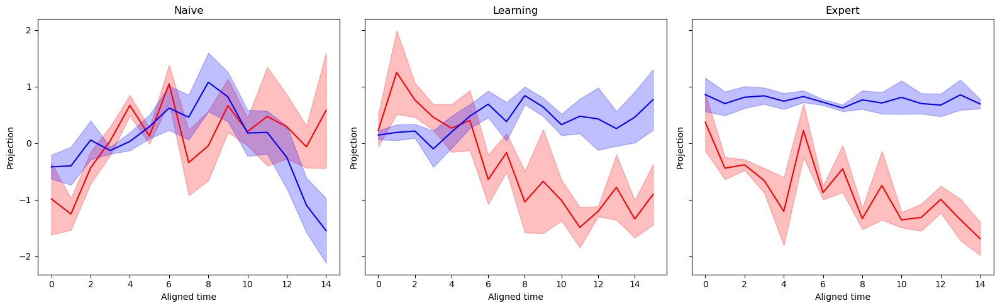

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize every pair of traces across select_agg_all_fov_proj_yes and select_agg_all_fov_proj_no together
# We'll iterate through trial indices. Each trial index corresponds to one array in each FOV.
# For each trial idx, pair up and normalize the yes/no traces across FOVs for that trial.
# We'll overwrite select_agg_all_fov_proj_yes and select_agg_all_fov_proj_no with normalized traces.

def minmax_pairwise_norm(traces1, traces2):
    # traces1 and traces2 are lists of arrays (FOVs) for a given trial index
    normalized1 = []
    normalized2 = []
    for t1, t2 in zip(traces1, traces2):
        # Align them to the same length (shortest)
        minlen = min(len(t1), len(t2))
        t1_a = t1[-minlen:]
        t2_a = t2[-minlen:]
        concat = np.concatenate([t1_a, t2_a])
        minv = np.min(concat)
        maxv = np.max(concat)
        denom = (maxv - minv) if maxv > minv else 1.0
        norm1 = (t1_a - minv) / denom
        norm2 = (t2_a - minv) / denom
        normalized1.append(norm1)
        normalized2.append(norm2)
    return normalized1, normalized2

def zscore_pairwise_norm(traces1, traces2):
    # traces1 and traces2 are lists of arrays (FOVs) for a given trial index
    normalized1 = []
    normalized2 = []
    for t1, t2 in zip(traces1, traces2):
        # Align them to the same length (shortest)
        minlen = min(len(t1), len(t2))
        t1_a = t1[-minlen:]
        t2_a = t2[-minlen:]
        concat = np.concatenate([t1_a, t2_a])
        mean = np.mean(concat)
        std = np.std(concat)
        std = std if std > 0 else 1.0
        norm1 = (t1_a - mean) / std
        norm2 = (t2_a - mean) / std
        normalized1.append(norm1)
        normalized2.append(norm2)
    return normalized1, normalized2


# Apply to all trial indices
n_trials = min(
    min(len(fov) for fov in select_agg_all_fov_proj_yes),
    min(len(fov) for fov in select_agg_all_fov_proj_no)
)
for trial_idx in range(n_trials):
    # For this trial idx, collect the traces for all FOVs (by index)
    yes_traces = [fov[trial_idx] for fov in select_agg_all_fov_proj_yes]
    no_traces = [fov[trial_idx] for fov in select_agg_all_fov_proj_no]
    norm_yes, norm_no = zscore_pairwise_norm(yes_traces, no_traces)
    # Replace original traces with normalized ones
    for fov_i, arr in enumerate(norm_yes):
        select_agg_all_fov_proj_yes[fov_i][trial_idx] = arr
    for fov_i, arr in enumerate(norm_no):
        select_agg_all_fov_proj_no[fov_i][trial_idx] = arr


def align_at_end_and_average_across_sessions(list_of_lists):
    """
    Given a list of lists: outer list = all FOVs (or sessions), inner list = trials,
    average across the FIRST item (trial 0) of every element (i.e., FOV), then second, then third, etc.
    There should be as many trials in each FOV as the inner length, usually 3.
    Returns: means and stds arrays (each trial index independently, after time-aligning).
    """
    n_fovs = len(list_of_lists)
    n_trials = min([len(sublist) for sublist in list_of_lists])
    means = []
    stds = []
    # For each trial index (0,1,2)
    for trial_i in range(n_trials):
        # Collect the trial_i traces from every FOV
        trial_across_fovs = [list_of_lists[fov_i][trial_i] for fov_i in range(n_fovs)]
        # Align at end (to shortest length)
        min_len = min([len(arr) for arr in trial_across_fovs])
        aligned = np.array([arr[-min_len:] for arr in trial_across_fovs])
        means.append(np.mean(aligned, axis=0))
        stds.append(np.std(aligned, axis=0))
    return means, stds  # lists of arrays, length n_trials

# For 'yes' and 'no'
# These are select_agg_all_fov_proj_yes: list of FOVs, each is a list of 3 arrays

yes_means, yes_stds = align_at_end_and_average_across_sessions(select_agg_all_fov_proj_yes)
no_means, no_stds = align_at_end_and_average_across_sessions(select_agg_all_fov_proj_no)

n_fovs = len(select_agg_all_fov_proj_yes)
n_trials = len(yes_means)  # Should be 3

titles = ['Naive', 'Learning', 'Expert']

fig, axes = plt.subplots(1, n_trials, figsize=(16,5), sharey=True)

for trial_i, ax in enumerate(axes):
    # Average across FOVs, for current trial
    mean_yes = yes_means[trial_i]
    std_yes = yes_stds[trial_i]
    mean_no = no_means[trial_i]
    std_no = no_stds[trial_i]
    n = n_fovs
    sem_yes = std_yes / np.sqrt(n)
    sem_no = std_no / np.sqrt(n)
    x = np.arange(len(mean_yes))
    ax.plot(x, mean_yes, color='red', label='yes', zorder=1)
    ax.fill_between(x, mean_yes - sem_yes, mean_yes + sem_yes, color='red', alpha=0.25, zorder=0)
    ax.plot( np.arange(len(mean_no)), mean_no, color='blue', label='no', zorder=1)
    ax.fill_between(np.arange(len(mean_no)), mean_no - sem_no, mean_no + sem_no, color='blue', alpha=0.25, zorder=0)
    ax.set_title(titles[trial_i])
    ax.set_xlabel("Aligned time")
    ax.set_ylabel("Projection")
    # ax.legend()

plt.tight_layout()
plt.savefig(r'P:\paperfigures\imagingELtraces.pdf')
plt.show()

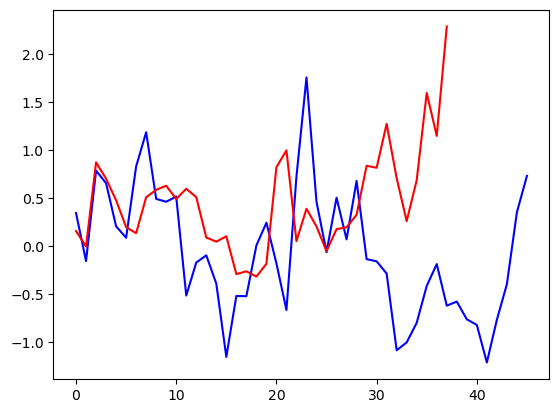

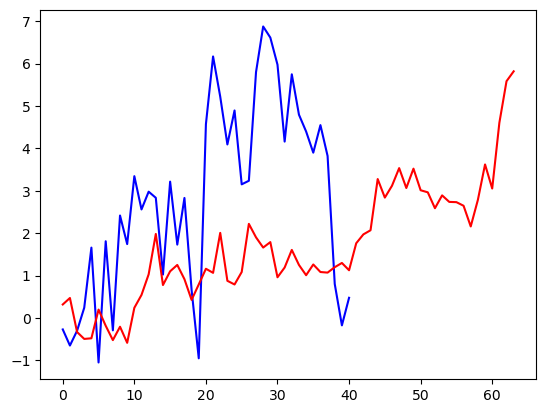

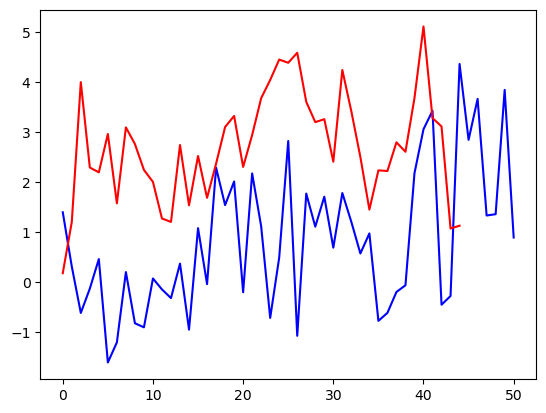

In [55]:
fovs = [5]
for fov in fovs:
    for i in range(3):
        plt.plot(-agg_all_fov_proj_yes[fov][i], color = 'blue')
        plt.plot(-agg_all_fov_proj_no[fov][i], color = 'red')
        plt.show()

### Correlation plots

- CD loadings
- decoding accuracy

In [ ]:
# decoding accuracy

# use cd from time t to predict LR from time t+1, t+2, t+3, etc...


all_cd_cors_nl = []
all_cd_cors_ne = []
all_cd_cors_le = []

for paths in all_matched_paths[1:2]:
    print(paths)

    naivepath, learningpath, expertpath,_ = paths
    
    # all neurons
    l1 = Mode(naivepath, use_reg = True, triple=True)

    l2 = Mode(learningpath, use_reg = True, triple=True)

    l3 = Mode(expertpath, use_reg = True, triple=True)

    cors_nl = []
    cors_ne = []
    cors_le = []

    for t in range(int(1.5*1/l1.fs), l1.time_cutoff - 2):
        orthonormal_basis_n, _ = l1.func_compute_epoch_decoder([l1.PSTH_r_train_correct, l1.PSTH_l_train_correct], epoch=range(t, t+2))
        orthonormal_basis_l, _ = l2.func_compute_epoch_decoder([l2.PSTH_r_train_correct, l2.PSTH_l_train_correct], epoch=range(t, t+2))
        orthonormal_basis_e, _ = l3.func_compute_epoch_decoder([l3.PSTH_r_train_correct, l3.PSTH_l_train_correct], epoch=range(t, t+2))

        # cors_nl.append(np.corrcoef(orthonormal_basis_n[0,:], orthonormal_basis_l[0,:])[0,1])
        # cors_ne.append(np.corrcoef(orthonormal_basis_n[0,:], orthonormal_basis_e[0,:])[0,1])
        # cors_le.append(np.corrcoef(orthonormal_basis_l[0,:], orthonormal_basis_e[0,:])[0,1])
        
        cors_nl.append(cosine_similarity(orthonormal_basis_n[0,:], orthonormal_basis_l[0,:]))
        cors_ne.append(cosine_similarity(orthonormal_basis_n[0,:], orthonormal_basis_e[0,:]))
        cors_le.append(cosine_similarity(orthonormal_basis_l[0,:], orthonormal_basis_e[0,:]))

    all_cd_cors_nl.append(cors_nl)
    all_cd_cors_ne.append(cors_ne)
    all_cd_cors_le.append(cors_le)

In [175]:
# CD loadings correlations across NLE stages
# take trial type or correct only
all_cd_cors_nl = []
all_cd_cors_ne = []
all_cd_cors_le = []

for paths in all_matched_paths:
    print(paths)

    naivepath, learningpath, expertpath = paths
    
    # all neurons
    l1 = Mode(naivepath, use_reg = True, triple=True)

    l2 = Mode(learningpath, use_reg = True, triple=True)

    l3 = Mode(expertpath, use_reg = True, triple=True)

    cors_nl = []
    cors_ne = []
    cors_le = []

    for t in range(int(1.5*1/l1.fs), l1.time_cutoff - 2):
        orthonormal_basis_n, _ = l1.func_compute_epoch_decoder([l1.PSTH_r_train_correct, l1.PSTH_l_train_correct], epoch=range(t, t+2))
        orthonormal_basis_l, _ = l2.func_compute_epoch_decoder([l2.PSTH_r_train_correct, l2.PSTH_l_train_correct], epoch=range(t, t+2))
        orthonormal_basis_e, _ = l3.func_compute_epoch_decoder([l3.PSTH_r_train_correct, l3.PSTH_l_train_correct], epoch=range(t, t+2))

        # cors_nl.append(np.corrcoef(orthonormal_basis_n[0,:], orthonormal_basis_l[0,:])[0,1])
        # cors_ne.append(np.corrcoef(orthonormal_basis_n[0,:], orthonormal_basis_e[0,:])[0,1])
        # cors_le.append(np.corrcoef(orthonormal_basis_l[0,:], orthonormal_basis_e[0,:])[0,1])
        
        cors_nl.append(cosine_similarity(orthonormal_basis_n[:, 0], orthonormal_basis_l[:, 0]))
        cors_ne.append(cosine_similarity(orthonormal_basis_n[:, 0], orthonormal_basis_e[:, 0]))
        cors_le.append(cosine_similarity(orthonormal_basis_l[:, 0], orthonormal_basis_e[:, 0]))

    all_cd_cors_nl.append(cors_nl)
    all_cd_cors_ne.append(cors_ne)
    all_cd_cors_le.append(cors_le)






['F:\\data\\BAYLORCW032\\python\\2023_10_05', 'F:\\data\\BAYLORCW032\\python\\2023_10_19', 'F:\\data\\BAYLORCW032\\python\\2023_10_24']
Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-0.3316837
-0.3316837
in house train test sorting
Sort by lick dir
Minimum cutoff is 61
No water leak!
normalizing
-0.547444
-0.547444
in house train test sorting
Sort by lick dir
Minimum cutoff is 61
No water leak!
normalizing
0.5582764
0.5582764
in house train test sorting
Sort by lick dir
Runtime: 0.006997346878051758 secs
Runtime: 0.002999544143676758 secs
Runtime: 0.0039997100830078125 secs
Runtime: 0.0029964447021484375 secs
Runtime: 0.0039997100830078125 secs
Runtime: 0.003000974655151367 secs
Runtime: 0.003997325897216797 secs
Runtime: 0.003998279571533203 secs
Runtime: 0.003998994827270508 secs
Runtime: 0.006994962692260742 secs
Runtime: 0.003003835678100586 secs
Runtime: 0.002992868423461914 secs
Runtime: 0.002995729446411133 secs
Runtime: 0.0030000209808349

In [188]:
len(all_cd_cors_ne[-1])

127

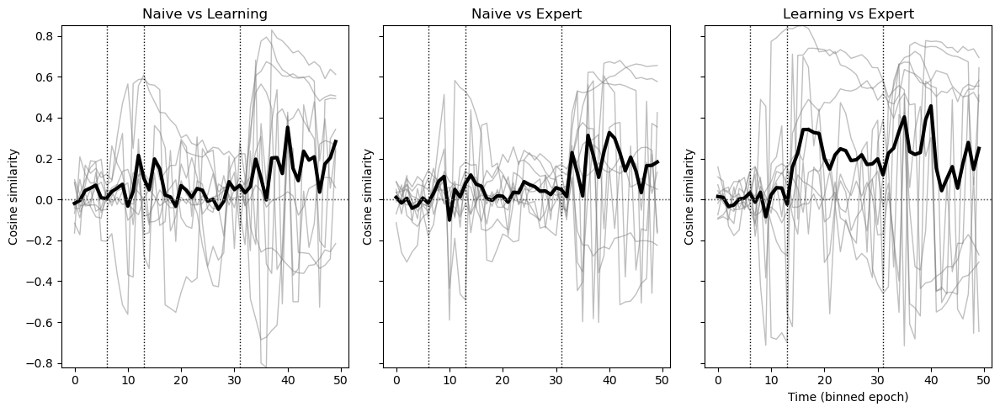

In [195]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1,3, figsize=(12, 5), sharey=True)

all_to_plot = [all_cd_cors_nl, all_cd_cors_ne, all_cd_cors_le]
titles = ['Naive vs Learning', 'Naive vs Expert', 'Learning vs Expert']

def interpolate_to_length(sess, target_len):
    """If session has more points than target_len, interpolate down."""
    sess = np.array(sess)
    if len(sess) > target_len:
        x_old = np.linspace(0, 1, len(sess))
        x_new = np.linspace(0, 1, target_len)
        sess_interp = np.interp(x_new, x_old, sess)
        return sess_interp
    else:
        return sess[:target_len]

all_to_plot_interp = []
for group in all_to_plot:
    min_len = min([len(sess) for sess in group])
    # For your updated instruction, this should be 50
    group_interp = [interpolate_to_length(sess, min_len) for sess in group]
    all_to_plot_interp.append(group_interp)

# Get min and max y for axis matching
global_min = min([np.min(np.array(sess)) for group in all_to_plot_interp for sess in group])
global_max = max([np.max(np.array(sess)) for group in all_to_plot_interp for sess in group])

for i, (cd_group, title) in enumerate(zip(all_to_plot_interp, titles)):
    min_len = min([len(sess) for sess in cd_group])
    trimmed_group = [np.array(sess[:min_len]) for sess in cd_group]
    cd_mat = np.stack(trimmed_group)

    # Plot individuals
    for sess in cd_mat:
        axs[i].plot(sess, color="grey", alpha=0.5, linewidth=1)
    # Plot mean
    axs[i].plot(np.mean(cd_mat, axis=0), color="k", linewidth=3, label='Mean')

    axs[i].set_ylim(global_min, global_max)
    axs[i].set_title(title)
    axs[i].set_ylabel('Cosine similarity')
for ax in axs:
    ax.axhline(0, linestyle=':', color='dimgray', linewidth=1)
    ax.axhline(0, linestyle=':', color='dimgray', linewidth=1)
    for xpos in [15-int(1.5*1/l1.fs), 22-int(1.5*1/l1.fs), 40-int(1.5*1/l1.fs)]:
        ax.axvline(x=xpos, linestyle=':', color='black', linewidth=1)


axs[-1].set_xlabel('Time (binned epoch)')
plt.tight_layout()
plt.show()

### Contra ipsi sankey

## Multiple CDs

In [193]:
l1.sample, l1.delay, l1.response

(15, 22, 40)

Minimum cutoff is 61
No water leak!
normalizing
-0.20815396
-0.20815396
in house train test sorting
Sort by lick dir
Runtime: 0.04700827598571777 secs


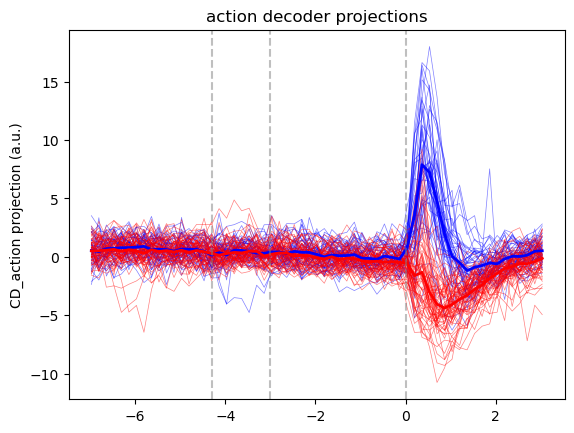

Minimum cutoff is 61
No water leak!
normalizing
-0.10009959


KeyboardInterrupt: 

In [192]:
# Delay and action CW37
naivepath, learningpath, expertpath=[r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',]
path = learningpath
l1 = Mode(path, use_reg = True, triple=True)
orthonormal_basis, mean = l1.plot_CD(mode_input='action', ctl=True)#, save = r'F:\data\Fig 2\CDstim_expert_CW46.pdf')

path = expertpath
l1 = Mode(path, use_reg = True, triple=True)
l1.plot_appliedCD(orthonormal_basis, mean)#, save = r'F:\data\Fig 2\CDstim_learning_CW46.pdf')

path = naivepath
l1 = Mode(path, use_reg = True, triple=True)
l1.plot_appliedCD(orthonormal_basis, mean)#,  save = r'F:\data\Fig 2\CDstim_naive_CW46.pdf')



path = learningpath
l1 = Mode(path, use_reg = True, triple=True)
orthonormal_basis, mean = l1.plot_CD(mode_input='choice', ctl=True)#, save = r'F:\data\Fig 2\CDstim_expert_CW46.pdf')

path = expertpath
l1 = Mode(path, use_reg = True, triple=True)
l1.plot_appliedCD(orthonormal_basis, mean)#, save = r'F:\data\Fig 2\CDstim_learning_CW46.pdf')

path = naivepath
l1 = Mode(path, use_reg = True, triple=True)
l1.plot_appliedCD(orthonormal_basis, mean)#,  save = r'F:\data\Fig 2\CDstim_naive_CW46.pdf')


Minimum cutoff is 151
No water leak!
normalizing
-0.5815296
-0.5815296
in house train test sorting
Sort by lick dir
Runtime: 0.00899505615234375 secs


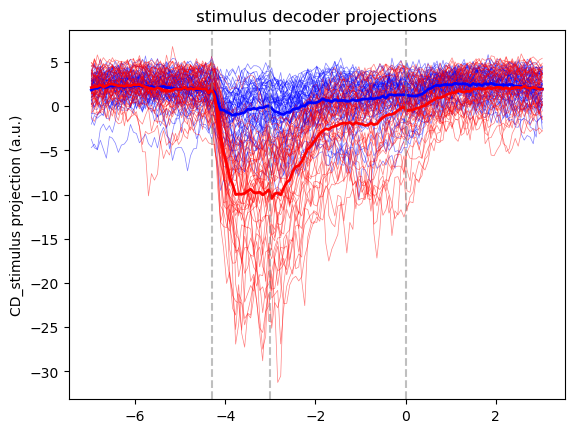

Minimum cutoff is 151
No water leak!
normalizing
0.38055593
0.38055593
in house train test sorting
Sort by lick dir


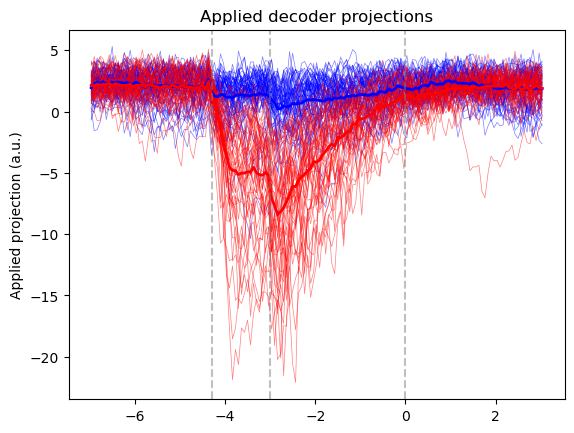

Minimum cutoff is 151
No water leak!
normalizing
-0.28290507
-0.28290507
in house train test sorting
Sort by lick dir


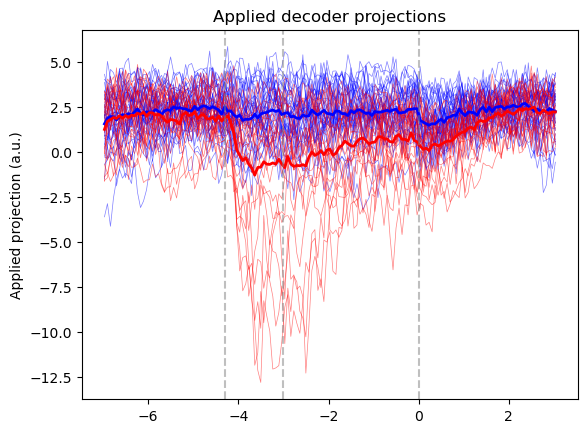

(array([1.5764443, 1.8806545, 1.9796467, 1.9671824, 1.793735 , 1.9733657,
        2.0908515, 2.0515194, 2.1444821, 2.059383 , 2.2409456, 2.4057171,
        2.1559577, 2.0656967, 2.2439249, 2.2281845, 2.2268448, 2.3673978,
        2.2736266, 2.0834808, 2.2939808, 2.357644 , 2.3243532, 2.525792 ,
        2.431466 , 2.4795318, 2.4226525, 2.4084532, 2.320988 , 2.2941177,
        2.5501251, 2.363792 , 2.51179  , 2.582574 , 2.525547 , 2.4210005,
        2.5304122, 2.4431994, 2.3394938, 2.1155026, 2.5262945, 2.2885308,
        2.2991645, 2.077401 , 1.955802 , 2.0563722, 1.7681412, 1.8361019,
        1.8241651, 1.8851098, 2.1189132, 1.9033635, 2.1313224, 2.1838806,
        2.2141597, 2.293084 , 2.3445826, 2.2634282, 2.333386 , 2.0844686,
        2.1708314, 2.2001193, 1.9702283, 1.994061 , 1.8901901, 1.8771801,
        2.076613 , 1.9968293, 2.0235395, 2.3446705, 2.1750028, 2.068583 ,
        2.1887248, 2.3338258, 2.1556528, 2.1308334, 2.0777848, 2.2925808,
        2.281228 , 2.1484215, 2.136422

In [7]:

#  Single FOV at learning stage - stim mode

paths =[r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',]

naivepath, learningpath, expertpath = [r'H:\data\BAYLORCW046\python\2024_05_31',
                    r'H:\data\BAYLORCW046\python\2024_06_11',
                  r'H:\data\BAYLORCW046\python\2024_06_26',]
path = learningpath
l1 = Mode(path, use_reg = True, triple=True)
orthonormal_basis, mean = l1.plot_CD(mode_input='stimulus', ctl=True)#, save = r'F:\data\Fig 2\CDstim_expert_CW46.pdf')

path = expertpath
l1 = Mode(path, use_reg = True, triple=True)
l1.plot_appliedCD(orthonormal_basis, mean)#, save = r'F:\data\Fig 2\CDstim_learning_CW46.pdf')

path = naivepath
l1 = Mode(path, use_reg = True, triple=True)
l1.plot_appliedCD(orthonormal_basis, mean)#,  save = r'F:\data\Fig 2\CDstim_naive_CW46.pdf')



## Selectivity and heatmap

Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
Empty selectivity vec: []
Empty selectivity vec: []


KeyboardInterrupt: 

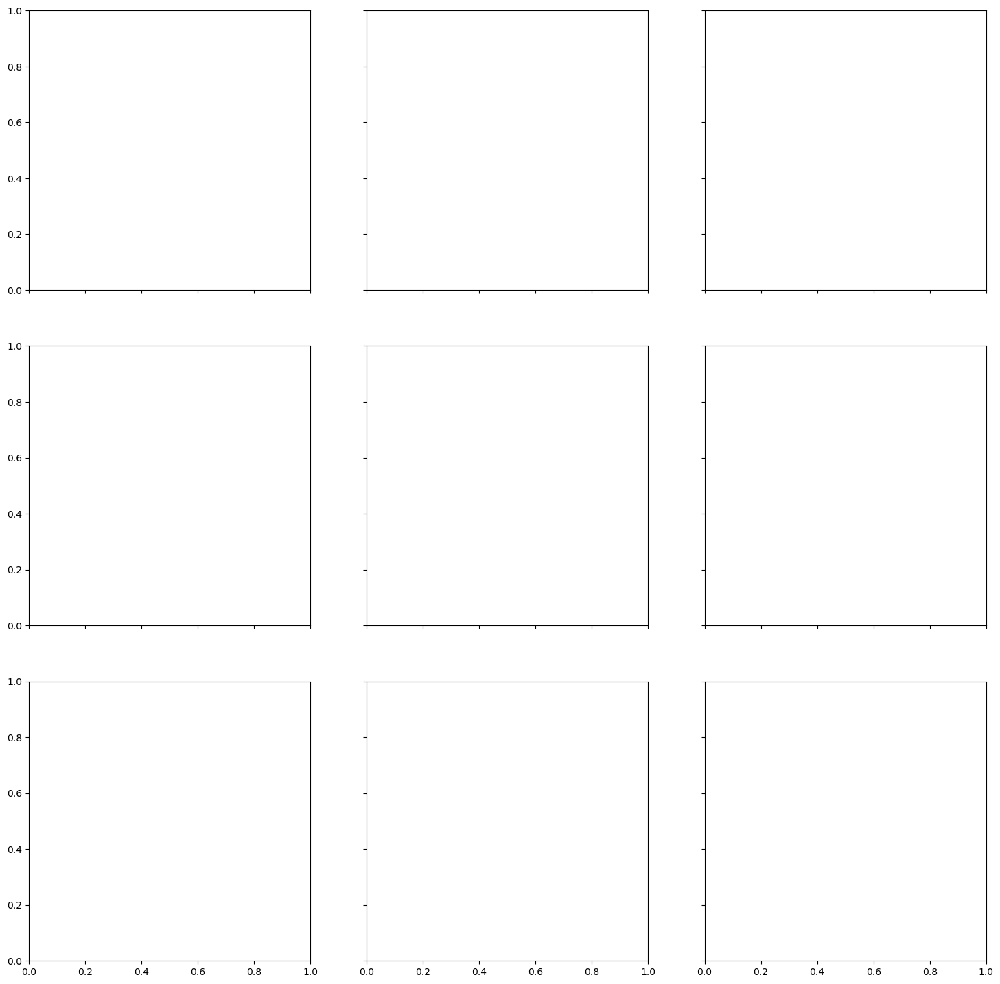

In [86]:
# Selectivity from SFN

agg_matched_paths = [[    
            r'F:\data\BAYLORCW032\python\2023_10_05',
            # r'F:\data\BAYLORCW034\python\2023_10_12',
            r'F:\data\BAYLORCW036\python\2023_10_09',
            r'F:\data\BAYLORCW035\python\2023_10_26',
            r'F:\data\BAYLORCW037\python\2023_11_21',
            

        r'H:\data\BAYLORCW044\python\2024_05_22',
        r'H:\data\BAYLORCW044\python\2024_05_23',
        
        r'H:\data\BAYLORCW046\python\2024_05_29',
        r'H:\data\BAYLORCW046\python\2024_05_30',
        r'H:\data\BAYLORCW046\python\2024_05_31',
            ],
             [r'F:\data\BAYLORCW032\python\2023_10_19',
            # r'F:\data\BAYLORCW034\python\2023_10_22',
            r'F:\data\BAYLORCW036\python\2023_10_19',
            r'F:\data\BAYLORCW035\python\2023_12_07',
            r'F:\data\BAYLORCW037\python\2023_12_08',

            
        r'H:\data\BAYLORCW044\python\2024_06_06',
        r'H:\data\BAYLORCW044\python\2024_06_04',

        r'H:\data\BAYLORCW046\python\2024_06_07',
        r'H:\data\BAYLORCW046\python\2024_06_10',
        r'H:\data\BAYLORCW046\python\2024_06_11',

        ],
        [r'F:\data\BAYLORCW032\python\2023_10_24',
            # r'F:\data\BAYLORCW034\python\2023_10_27',
            r'F:\data\BAYLORCW036\python\2023_10_30',
            r'F:\data\BAYLORCW035\python\2023_12_15',
            r'F:\data\BAYLORCW037\python\2023_12_15',
            
            
            r'H:\data\BAYLORCW044\python\2024_06_19',
            r'H:\data\BAYLORCW044\python\2024_06_18',
            
            r'H:\data\BAYLORCW046\python\2024_06_24',
            r'H:\data\BAYLORCW046\python\2024_06_27',
            r'H:\data\BAYLORCW046\python\2024_06_26',

        ]]


f, axarr = plt.subplots(3,3, sharey='row', sharex = True, figsize=(18,18))
# plt.setp(axarr, ylim=(-0.2,1.2))

for j in range(3):
    
    stimnonpref, stimpref = np.zeros(61), np.zeros(61)
    choicenonpref, choicepref = np.zeros(61), np.zeros(61)
    actionnonpref, actionpref = np.zeros(61), np.zeros(61)
    
    for path in agg_matched_paths[j]:
        l1 = session.Session(path, use_reg=True, triple=True)
        # adjusted_p = 0.05 / np.sqrt(len(l1.good_neurons))
        adjusted_p = 0.01
        _, _, _, numoutcome, stim_sel, choice_sel, outcome_sel, action_sel = l1.stim_choice_outcome_selectivity(plot=False, p=adjusted_p,
                                                                                                                downsample='04' in path)
        snp, sp = stim_sel
        if len(snp) != 0 and np.sum(snp) != 0:
            stimnonpref = np.vstack((stimnonpref, snp))
            stimpref = np.vstack((stimpref, sp))
        
        snp, sp = choice_sel
        if len(snp) != 0 and np.sum(snp) != 0:

            choicenonpref = np.vstack((choicenonpref, snp))
            choicepref = np.vstack((choicepref, sp))
         
        snp, sp = action_sel
        if len(snp) != 0 and np.sum(snp) != 0:
    
            actionnonpref = np.vstack((actionnonpref, snp))
            actionpref = np.vstack((actionpref, sp))
            
    print(len(stimpref), len(choicepref), len(actionpref))

    x = np.arange(-6.97,4,1/6)[:61]
    titles = ['Stimulus selective', 'Choice selective', 'Outcome selective', 'Action selective']
    
    stimnonpref, stimpref = stimnonpref[1:,:], stimpref[1:,:]
    choicenonpref, choicepref = choicenonpref[1:,:], choicepref[1:,:]
    actionnonpref, actionpref = actionnonpref[1:,:], actionpref[1:,:]
    
    err = np.std((stimpref - stimnonpref), axis=0) / np.sqrt(len(stimpref)) 
    sel = np.mean((stimpref - stimnonpref), axis=0)
    axarr[0,j].plot(x, sel, color='green')
            
    axarr[0,j].fill_between(x, sel - err, 
              sel + err,
              color='lightgreen')
    
    axarr[0,j].set_title(titles[0])
    
    err = np.std((choicepref - choicenonpref), axis=0) / np.sqrt(len(choicepref)) 
    sel = np.mean((choicepref - choicenonpref), axis=0)
    # err = np.std(choicepref, axis=0) / np.sqrt(len(choicepref)) 
    # err += np.std(choicenonpref, axis=0) / np.sqrt(len(choicenonpref))
    # sel = np.mean(choicepref, axis=0) - np.mean(choicenonpref, axis=0) 
    axarr[1,j].plot(x, sel, color='purple')
            
    axarr[1,j].fill_between(x, sel - err, 
              sel + err,
              color='violet')
    axarr[1,j].set_title(titles[1])
    
    err = np.std((actionpref - actionnonpref), axis=0) / np.sqrt(len(actionpref)) 
    sel = np.mean((actionpref - actionnonpref), axis=0)
    # err = np.std(actionpref, axis=0) / np.sqrt(len(actionpref)) 
    # err += np.std(actionnonpref, axis=0) / np.sqrt(len(actionnonpref))
    # sel = np.mean(actionpref, axis=0) - np.mean(actionnonpref, axis=0) 
    axarr[2,j].plot(x, sel, color='goldenrod')
            
    axarr[2,j].fill_between(x, sel - err, 
              sel + err,
              color='wheat')
    
    axarr[2,j].set_title(titles[3])
    
    
for i in range(3):
    for j in range(3):
        axarr[j,i].axvline(0, color = 'grey', alpha=0.5, ls = '--')
        axarr[j,i].axvline(-4.3, color = 'grey', alpha=0.5, ls = '--')
        axarr[j,i].axvline(-3, color = 'grey', alpha=0.5, ls = '--')        
        axarr[j,i].axhline(0, color = 'grey', alpha=0.5, ls = '--')
        
        
axarr[0,0].set_ylabel('Selectivity')
axarr[2,1].set_xlabel('Time from Go cue (s)')



# plt.savefig(r'F:\data\Fig 2\NLE_all_selectivityagg_new_p01.pdf')
plt.show()

## Cell matching figs

In [85]:
# total number of neurons at each learning stage vs total matched across all three stages (shows that there is not signfiicant exclusion)
naivecount, learningcount, expertcount, matchedcount = [],[],[],[]

for paths in all_matched_paths:
    print(paths)

    naivepath, learningpath, expertpath = paths
    
    # all neurons
    l1 = session.Session(naivepath, use_reg=False, triple=False)
    naivecount.append(l1.num_neurons)

    l1 = session.Session(learningpath, use_reg=False, triple=False)
    learningcount.append(l1.num_neurons)

    l1 = session.Session(expertpath, use_reg=False, triple=False)
    expertcount.append(l1.num_neurons)

    # all matched 
    l1 = session.Session(expertpath, use_reg=True, triple=True, filter_reg = False)
    matchedcount.append(len(l1.good_neurons))

    # all matched filtered
    # l1 = Session(path, use_reg=True, triple=True)
    # print(len(l1.good_neurons))


['F:\\data\\BAYLORCW032\\python\\2023_10_05', 'F:\\data\\BAYLORCW032\\python\\2023_10_19', 'F:\\data\\BAYLORCW032\\python\\2023_10_24']
Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
['F:\\data\\BAYLORCW036\\python\\2023_10_09', 'F:\\data\\BAYLORCW036\\python\\2023_10_19', 'F:\\data\\BAYLORCW036\\python\\2023_10_30']
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Using Pearsons corr to 

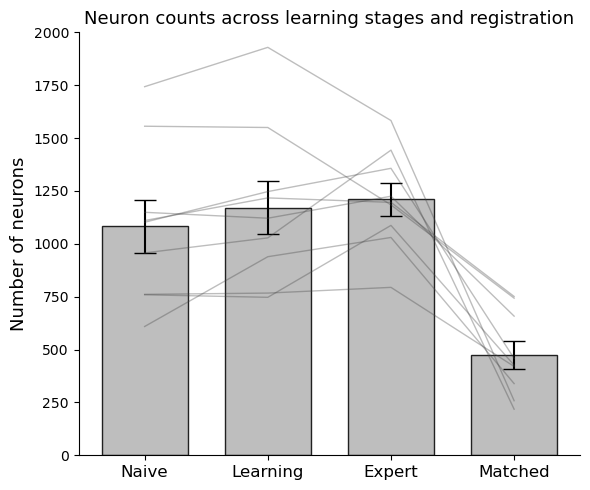

In [94]:

# Prepare data
counts = [naivecount, learningcount, expertcount, matchedcount]
labels = ["Naive", "Learning", "Expert", "Matched"]
means = [np.mean(c) for c in counts]
sems = [np.std(c, ddof=1) / np.sqrt(len(c)) for c in counts]
num_sessions = len(naivecount)

fig, ax = plt.subplots(figsize=(6,5))

bar_positions = np.arange(4)
bar_width = 0.7

# Plot bars for means: grey bars, black outlines
bars = ax.bar(
    bar_positions, means, yerr=sems,
    color=['0.7']*4,  # all grey fill
    edgecolor='black',
    width=bar_width,
    alpha=0.85,
    zorder=2,
    capsize=8,
    ecolor='black'
)

# Overlay all session lines
for sess in range(num_sessions):
    y = [counts[i][sess] for i in range(4)]
    # You can add x jitter if you want to display dots, but line-on-bars is fine as is
    ax.plot(bar_positions, y, color='#444', alpha=0.35, linewidth=1, zorder=4)

# Set labels and presentation
ax.set_xticks(bar_positions)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Number of neurons', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("Neuron counts across learning stages and registration", fontsize=13)
# ax.grid(axis='y', linestyle=':', alpha=0.45, zorder=1)
ax.set_ylim(0, 2000)
plt.tight_layout()
plt.savefig(r'P:\paperfigures\n_count.pdf')
plt.show()

In [87]:
# Fracion of matched neurons over all FOVs across the three learning stages

naiveprop = np.array(matchedcount) / np.array(naivecount)
learningprop = np.array(matchedcount) / np.array(learningcount)
expertprop = np.array(matchedcount) / np.array(expertcount)

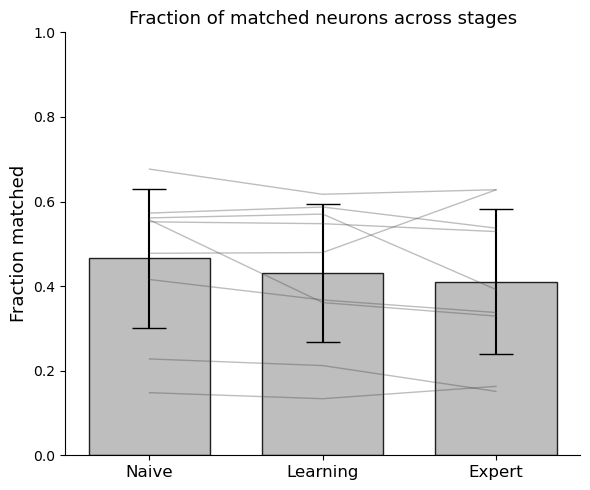

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Organize the data
props = [naiveprop, learningprop, expertprop]
labels = ["Naive", "Learning", "Expert"]
means = [np.mean(p) for p in props]
stds = [np.std(p) for p in props]
num_sessions = len(naiveprop)

bar_positions = np.arange(3)
bar_width = 0.7

fig, ax = plt.subplots(figsize=(6,5))

# Plot bars with error bars (std), all grey with black outlines
bars = ax.bar(
    bar_positions, means, yerr=stds,
    color=['0.7']*3,  # grey fill for all bars
    edgecolor='black',
    width=bar_width,
    alpha=0.85,
    zorder=2,
    capsize=12,
    ecolor='black'
)

# Connect each session's values with a line only (no scatter/points)
for sess in range(num_sessions):
    y = [props[i][sess] for i in range(3)]
    ax.plot(bar_positions, y, color='#444', alpha=0.35, linewidth=1, zorder=4)

ax.set_xticks(bar_positions)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Fraction matched', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("Fraction of matched neurons across stages", fontsize=13)
# ax.grid(axis='y', linestyle=':', alpha=0.45, zorder=1)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig(r'P:\paperfigures\frac_matched_n.pdf')

plt.show()

### Cellreg measures

In [ ]:
# Centroid distance vs spatial footprint correlation


